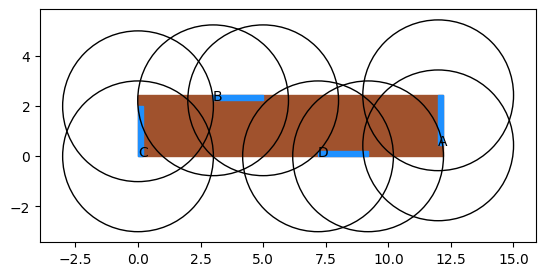

In [183]:
import matplotlib.pyplot as plt
import numpy as np
# lengths in meters
shadow_length = 3.01137439397
visual_panel_thickness = .2
panel_length = 2

sled_width = 12.192 
sled_height = 2.4384

B_D_spacing_diff = 3

sled = plt.Rectangle((0, 0), width = sled_width, height = sled_height, facecolor = 'sienna', edgecolor = 'sienna')

A_pos = (sled_width - visual_panel_thickness, sled_height - panel_length)
B_pos = (0 + B_D_spacing_diff, sled_height - visual_panel_thickness)
C_pos = (0, 0)
D_pos = (sled_width - panel_length - B_D_spacing_diff, 0)
panel_A = plt.Rectangle(A_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
panel_B = plt.Rectangle(B_pos, width = panel_length, height = visual_panel_thickness, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
panel_C = plt.Rectangle(C_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
panel_D = plt.Rectangle(D_pos, width = panel_length, height = visual_panel_thickness, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')


shadow_A_1 = plt.Circle((A_pos[0],A_pos[1]), shadow_length, facecolor = 'black', edgecolor = 'black',fill =False)
shadow_A_2 = plt.Circle((A_pos[0],A_pos[1]+panel_length), shadow_length, facecolor = 'black', edgecolor = 'black', fill =False)

shadow_B_1 = plt.Circle((B_pos[0],B_pos[1]), shadow_length, facecolor = 'black', edgecolor = 'black', fill =False)
shadow_B_2 = plt.Circle(((B_pos[0]+ panel_length,B_pos[1])), shadow_length, facecolor = 'black', edgecolor = 'black', fill =False)

shadow_C_1 = plt.Circle((C_pos[0],C_pos[1]), shadow_length, facecolor = 'black', edgecolor = 'black',fill =False)
shadow_C_2 = plt.Circle((C_pos[0],C_pos[1]+panel_length), shadow_length, facecolor = 'black', edgecolor = 'black', fill =False)

shadow_D_1 = plt.Circle((D_pos[0],D_pos[1]), shadow_length, facecolor = 'black', edgecolor = 'black', fill =False)
shadow_D_2 = plt.Circle((D_pos[0]+panel_length,D_pos[1]), shadow_length, facecolor = 'black', edgecolor = 'black', fill =False)

ax = plt.gca()
ax.add_patch(sled)
ax.add_patch(panel_A)
ax.add_patch(panel_B)
ax.add_patch(panel_C)
ax.add_patch(panel_D)

ax.add_patch(shadow_A_1)
ax.add_patch(shadow_A_2)
ax.add_patch(shadow_B_1)
ax.add_patch(shadow_B_2)
ax.add_patch(shadow_C_1)
ax.add_patch(shadow_C_2)
ax.add_patch(shadow_D_1)
ax.add_patch(shadow_D_2)

ax.text(A_pos[0], A_pos[1], 'A')
ax.text(B_pos[0], B_pos[1], 'B')
ax.text(C_pos[0], C_pos[1], 'C')
ax.text(D_pos[0], D_pos[1], 'D')
# ax.text(-1,-1, f'{sled_width}m', size=20)

plt.axis('scaled')
plt.show()




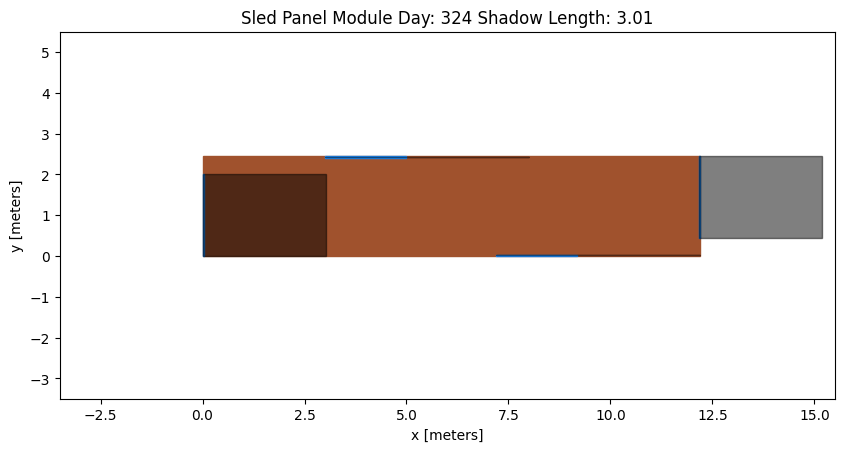

In [184]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.animation as animation
fig, ax = plt.subplots(figsize = (10,8))

solar_azimuths = np.linspace(0,360, 10)
day = 324
shadow_length = 3.01137439397

visual_panel_thickness = .03
panel_length = 2

sled_width = 12.192 
sled_height = 2.4384

B_D_spacing_diff = 3

sled = plt.Rectangle((0, 0), width = sled_width, height = sled_height, facecolor = 'sienna', edgecolor = 'sienna')

A_pos = (sled_width - visual_panel_thickness, sled_height - panel_length)
B_pos = (0 + B_D_spacing_diff, sled_height - visual_panel_thickness)
C_pos = (0, 0)
D_pos = (sled_width - panel_length - B_D_spacing_diff, 0)




def animate(i):
    
    ax.clear()

    ax.set_xlim(-3.5,15.5)
    ax.set_ylim(-3.5,5.5)
    ax.set_title(f'Sled Panel Module Day: {day} Shadow Length: {np.round(shadow_length, 2)}')
    ax.set_xlabel('x [meters]')
    ax.set_ylabel('y [meters]')
    solar_azimuth = i
    # lengths in meters

    
    panel_A = plt.Rectangle(A_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_B = plt.Rectangle(B_pos, width = panel_length, height = visual_panel_thickness, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_C = plt.Rectangle(C_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_D = plt.Rectangle(D_pos, width = panel_length, height = visual_panel_thickness, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    
    ax.add_patch(sled)
    ax.add_patch(panel_A)
    ax.add_patch(panel_B)
    ax.add_patch(panel_C)
    ax.add_patch(panel_D)

    solar_azimuth = solar_azimuth*np.pi/180  #enter in degrees
    
    
    
    A_shadow_points = [(A_pos[0]+visual_panel_thickness/2,A_pos[1]),(A_pos[0]+visual_panel_thickness/2,A_pos[1]+panel_length),(A_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),A_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(A_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),A_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_A = Polygon(A_shadow_points, color = 'black', alpha = .5)
    
    
    B_shadow_points = [(B_pos[0],visual_panel_thickness/2+B_pos[1]),(B_pos[0]+panel_length,visual_panel_thickness/2+B_pos[1]),(B_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+B_pos[1]+ shadow_length*np.sin(solar_azimuth)),(B_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+B_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_B = Polygon(B_shadow_points, color = 'black', alpha = .5)
    
    
    C_shadow_points = [(C_pos[0]+visual_panel_thickness/2,C_pos[1]),(C_pos[0]+visual_panel_thickness/2,C_pos[1]+panel_length),(C_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),C_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(C_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),C_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_C = Polygon(C_shadow_points, color = 'black', alpha = .5)
    
    
    D_shadow_points = [(D_pos[0],visual_panel_thickness/2+D_pos[1]),(D_pos[0]+panel_length,visual_panel_thickness/2+D_pos[1]),(D_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+D_pos[1]+ shadow_length*np.sin(solar_azimuth)),(D_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+D_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_D = Polygon(D_shadow_points, color = 'black', alpha = .5)


    ax.add_patch(shadow_A)
    ax.add_patch(shadow_B)
    ax.add_patch(shadow_C)
    ax.add_patch(shadow_D)

    # ax = plt.gca()

    
    # return shadow_A, shadow_B, shadow_C, shadow_D
    # ax.add_patch(shadow_A_2)
    # ax.add_patch(shadow_B_1)
    # ax.add_patch(shadow_B_2)
    # ax.add_patch(shadow_C_1)
    # ax.add_patch(shadow_C_2)
    # ax.add_patch(shadow_D_1)
    # ax.add_patch(shadow_D_2)





ax.text(A_pos[0], A_pos[1], 'A')
ax.text(B_pos[0], B_pos[1], 'B')
ax.text(C_pos[0], C_pos[1], 'C')
ax.text(D_pos[0], D_pos[1], 'D')
# ax.text(-1,-1, f'{sled_width}m', size=20)

plt.axis('scaled')
# plt.show()
ani = animation.FuncAnimation(
    fig, animate, interval=1, blit=False, frames = 360)
writer = animation.PillowWriter(fps=10,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
ani.save('SledArray.gif', writer=writer)





66.96952083333335
23.03047916666665
2.3523723553853015
3.1078946199231496


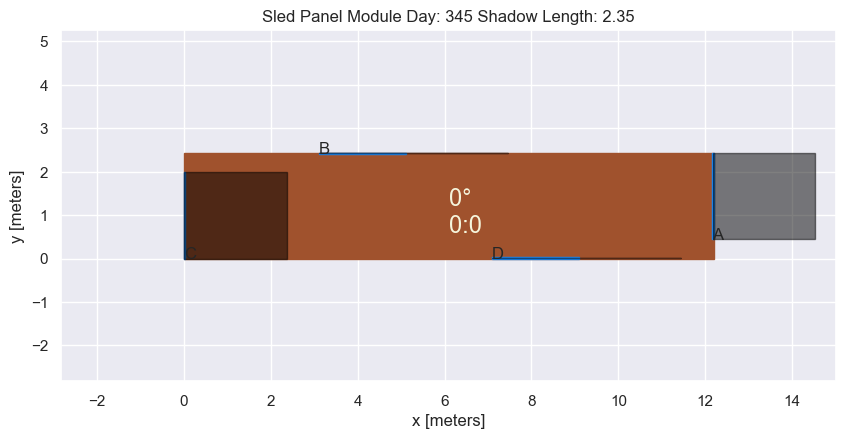

In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin
import seaborn as sns
import math
from VerticalModelFunction import model as VerticalModel


# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'






# import NOAA data function
def Import_NOAA_Data(year, day):
    input_1 = year
    input_2 = day
    # -----------------NOAA-----------------------------------
    NOAA = [] #list to hold dataframes
    for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
        iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
        filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
        # print(filename) #print the filename being accessed
    
        try:
            file = urllib.request.urlopen(filename)
            data = file.read().decode('utf-8').split('\n') #read the file and split into lines
            #convert data to dataframe
            df = pd.DataFrame([row.split() for row in data[2:]])
            # print(dt)
            NOAA.append(df) #append dataframe to list
        except urllib.error.HTTPError:
            print()
            # print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    NOAAdir_ir_1 = NOAA[0][12]
    NOAAdir_ir_2 = NOAA[1][12]
    NOAAtemp = NOAA[0][38]
    # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
    # print(f'NOAAtemp: {NOAAtemp}')
    # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
    # concatenate the two days data with time correction
    NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))

    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    # diffuse irradiance
    NOAAdiff_ir_1 = NOAA[0][14]
    NOAAdiff_ir_2 = NOAA[1][14]
    
    # concatenate the two days data with time correction
    NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    NOAAup_ir_1 = NOAA[0][10] 
    NOAAup_ir_2 = NOAA[1][10]
    NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDTup_ir = NZDTup_ir.astype(float)
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula

    '''Solar Zenith Angle'''
    NOAA_Zenith_1 = NOAA[0][7] 
    NOAA_Zenith_2 = NOAA[1][7]
    NZDT_Zenith= pd.concat([NOAA_Zenith_1.iloc[660:1440], NOAA_Zenith_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDT_Zenith = NZDT_Zenith.astype(float)
    #remove nan values from NZDTup_ir 
    NZDT_Zenith[NZDT_Zenith == -9999.9] = np.nan
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time, NZDT_Zenith


day = 345
year = 25

direct_irradiance, diffuse_irradiance, upwelling_irradiance, NOAA_time, solar_zenith = Import_NOAA_Data(year,day)

solar_azimuths = np.linspace(0,360, 10)

solar_zenith_mean = np.nanmean(solar_zenith)
print(solar_zenith_mean)

solar_elevation = 90 - solar_zenith_mean
print(solar_elevation)

panel_height = 1
panel_lift = 0
shadow_length = (panel_height+panel_lift)/np.tan(solar_elevation*np.pi/180)
print(shadow_length)
visual_panel_thickness = .03
panel_length = 2

sled_width = 12.192 
sled_height = 2.4384


# B_D_spacing_diff = (1/2)*(sled_width-((1/3)*(-1*sled_width+np.sqrt(sled_width**2+3*(sled_width**2-8*sled_height*panel_length+4*panel_length**2))))) - panel_length
B_D_spacing_diff = (1/3)*((-1)*np.sqrt(sled_width**2-4*sled_width*panel_length+7*panel_length**2-6*panel_length*sled_height)+2*sled_width-4*panel_length)
print(B_D_spacing_diff)





fig, ax = plt.subplots(figsize = (10,8))

sled = plt.Rectangle((0, 0), width = sled_width, height = sled_height, facecolor = 'sienna', edgecolor = 'sienna')

A_pos = (sled_width - visual_panel_thickness, sled_height - panel_length)
B_pos = (0 + B_D_spacing_diff, sled_height - visual_panel_thickness)
C_pos = (0, 0)
D_pos = (sled_width - panel_length - B_D_spacing_diff, 0)




def animate(i):
    
    ax.clear()
    ax.grid(True)

    ax.set_xlim(-shadow_length -.2*shadow_length,shadow_length+.2*shadow_length+sled_width)
    ax.set_ylim(-shadow_length -.2*shadow_length,shadow_length+.2*shadow_length+sled_height)
    ax.set_title(f'Sled Panel Module Day: {day} Shadow Length: {np.round(shadow_length, 2)}')
    ax.set_xlabel('x [meters]')
    ax.set_ylabel('y [meters]')
    solar_azimuth = i
    # lengths in meters

    
    panel_A = plt.Rectangle(A_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_B = plt.Rectangle(B_pos, width = panel_length, height = visual_panel_thickness, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_C = plt.Rectangle(C_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_D = plt.Rectangle(D_pos, width = panel_length, height = visual_panel_thickness, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    
    ax.add_patch(sled)
    ax.add_patch(panel_A)
    ax.add_patch(panel_B)
    ax.add_patch(panel_C)
    ax.add_patch(panel_D)

    solar_azimuth = solar_azimuth*np.pi/180  #enter in degrees
    
    
    
    A_shadow_points = [(A_pos[0]+visual_panel_thickness/2,A_pos[1]),(A_pos[0]+visual_panel_thickness/2,A_pos[1]+panel_length),(A_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),A_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(A_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),A_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_A = Polygon(A_shadow_points, color = 'black', alpha = .5)
    
    
    B_shadow_points = [(B_pos[0],visual_panel_thickness/2+B_pos[1]),(B_pos[0]+panel_length,visual_panel_thickness/2+B_pos[1]),(B_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+B_pos[1]+ shadow_length*np.sin(solar_azimuth)),(B_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+B_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_B = Polygon(B_shadow_points, color = 'black', alpha = .5)
    
    
    C_shadow_points = [(C_pos[0]+visual_panel_thickness/2,C_pos[1]),(C_pos[0]+visual_panel_thickness/2,C_pos[1]+panel_length),(C_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),C_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(C_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),C_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_C = Polygon(C_shadow_points, color = 'black', alpha = .5)
    
    
    D_shadow_points = [(D_pos[0],visual_panel_thickness/2+D_pos[1]),(D_pos[0]+panel_length,visual_panel_thickness/2+D_pos[1]),(D_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+D_pos[1]+ shadow_length*np.sin(solar_azimuth)),(D_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+D_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_D = Polygon(D_shadow_points, color = 'black', alpha = .5)


    ax.add_patch(shadow_A)
    ax.add_patch(shadow_B)
    ax.add_patch(shadow_C)
    ax.add_patch(shadow_D)

    ax.text(A_pos[0], A_pos[1], 'A')
    ax.text(B_pos[0], B_pos[1], 'B')
    ax.text(C_pos[0], C_pos[1], 'C')
    ax.text(D_pos[0], D_pos[1], 'D')
    ax.text(sled_width/2,sled_height/2,f'{i}°', fontsize = 17, color = 'beige')
    ax.text(sled_width/2,sled_height/4,f'{math.floor(i/15)}:{math.floor((np.round(i/15,2)-math.floor(i/15))*60)}', fontsize = 17, color = 'beige')
    sns.set_theme(style = 'darkgrid')
    
    # ax = plt.gca()

    
    # return shadow_A, shadow_B, shadow_C, shadow_D
    # ax.add_patch(shadow_A_2)
    # ax.add_patch(shadow_B_1)
    # ax.add_patch(shadow_B_2)
    # ax.add_patch(shadow_C_1)
    # ax.add_patch(shadow_C_2)
    # ax.add_patch(shadow_D_1)
    # ax.add_patch(shadow_D_2)






# ax.text(-1,-1, f'{sled_width}m', size=20)

plt.axis('scaled')
# plt.show()
ani = animation.FuncAnimation(
    fig, animate, interval=1, blit=False, frames = 360)
writer = animation.PillowWriter(fps=15,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
ani.save('SledArray.gif', writer=writer)

66.96952083333335
23.03047916666665
2.3523723553853015
3.1078946199231496



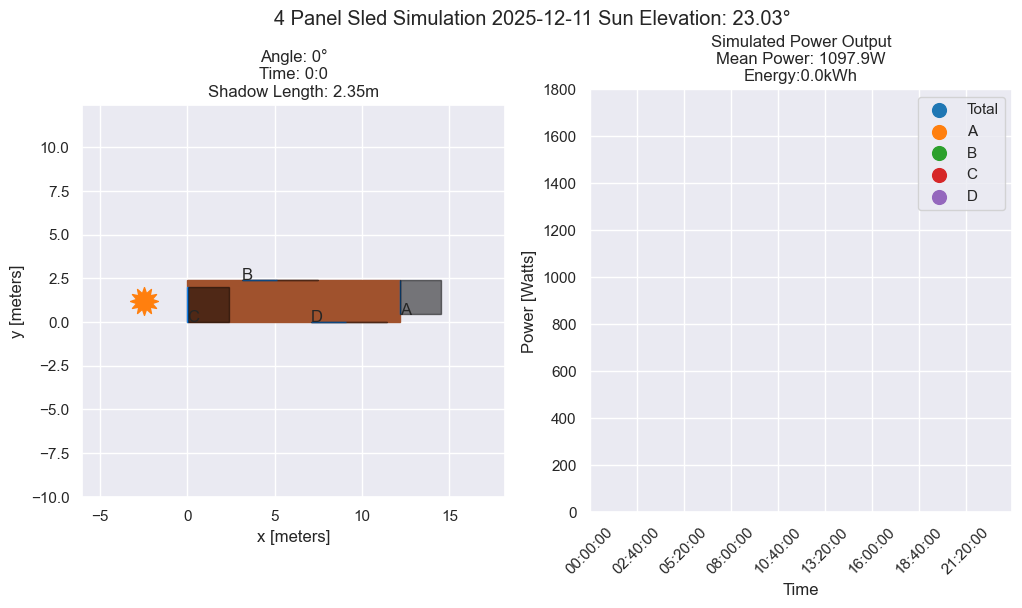

In [27]:

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin
import seaborn as sns
import math
from VerticalModelFunction import model as VerticalModel
import datetime


# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'

effs= [0.24699832280882955,0.03850296370170911, 0.05890744297245301]

def serial_date_to_string(year,srl_no):
    '''
    This function turns a day number and year to human readable date. Stole from stack overflow with minor modifactions
    '''
    # This will only work for years in this millenium!
    year_2 = year+2000
    # we need to use a 2 digit year
    new_date = datetime.datetime(year_2,1,1,0,0) + datetime.timedelta(srl_no - 1)
    return new_date.strftime("%Y-%m-%d")


# import NOAA data function
def Import_NOAA_Data(year, day):
    input_1 = year
    input_2 = day
    # -----------------NOAA-----------------------------------
    NOAA = [] #list to hold dataframes
    for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
        iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
        filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
        # print(filename) #print the filename being accessed
    
        try:
            file = urllib.request.urlopen(filename)
            data = file.read().decode('utf-8').split('\n') #read the file and split into lines
            #convert data to dataframe
            df = pd.DataFrame([row.split() for row in data[2:]])
            # print(dt)
            NOAA.append(df) #append dataframe to list
        except urllib.error.HTTPError:
            print()
            # print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    NOAAdir_ir_1 = NOAA[0][12]
    NOAAdir_ir_2 = NOAA[1][12]
    NOAAtemp = NOAA[0][38]
    # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
    # print(f'NOAAtemp: {NOAAtemp}')
    # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
    # concatenate the two days data with time correction
    NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))

    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    # diffuse irradiance
    NOAAdiff_ir_1 = NOAA[0][14]
    NOAAdiff_ir_2 = NOAA[1][14]
    
    # concatenate the two days data with time correction
    NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    NOAAup_ir_1 = NOAA[0][10] 
    NOAAup_ir_2 = NOAA[1][10]
    NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDTup_ir = NZDTup_ir.astype(float)
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula

    '''Solar Zenith Angle'''
    NOAA_Zenith_1 = NOAA[0][7] 
    NOAA_Zenith_2 = NOAA[1][7]
    NZDT_Zenith= pd.concat([NOAA_Zenith_1.iloc[660:1440], NOAA_Zenith_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDT_Zenith = NZDT_Zenith.astype(float)
    #remove nan values from NZDTup_ir 
    NZDT_Zenith[NZDT_Zenith == -9999.9] = np.nan
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time, NZDT_Zenith


day = 345
year = 25

direct_irradiance, diffuse_irradiance, upwelling_irradiance, NOAA_time, solar_zenith = Import_NOAA_Data(year,day)

solar_azimuths = np.linspace(0,360, 10)

solar_zenith_mean = np.nanmean(solar_zenith)
print(solar_zenith_mean)

solar_elevation = 90 - solar_zenith_mean
print(solar_elevation)

panel_height = 1
panel_lift = 0
shadow_length = (panel_height+panel_lift)/np.tan(solar_elevation*np.pi/180)
print(shadow_length)
visual_panel_thickness = .03
panel_length = 2

sled_width = 12.192 
sled_height = 2.4384



# B_D_spacing_diff = (1/2)*(sled_width-((1/3)*(-1*sled_width+np.sqrt(sled_width**2+3*(sled_width**2-8*sled_height*panel_length+4*panel_length**2))))) - panel_length
B_D_spacing_diff = (1/3)*((-1)*np.sqrt(sled_width**2-4*sled_width*panel_length+7*panel_length**2-6*panel_length*sled_height)+2*sled_width-4*panel_length)
print(B_D_spacing_diff)

if shadow_length>B_D_spacing_diff:
    WarningMessage = 'WARNING: SHADING IS PRESENT\nSIMULATION UNTRUSTWORTHY'
else:
    WarningMessage = ''
print(WarningMessage)
    

# lets find the power output from VerticalModelFunction

angles = [0,90,180,270]

sim_powers = []
for a in angles:
    sim_power = VerticalModel(direct_irradiance, diffuse_irradiance, upwelling_irradiance, effs, 50, solar_zenith_mean, 360-a-90) #there was an error in defining my angle, mismatch the picuture and the model by 90, I correct it here
    sim_powers.append(sim_power)
total_power = np.array(sim_powers).sum(axis=0)
sim_A, sim_B, sim_C, sim_D = sim_powers

mean_power = np.nanmean(total_power)





fig, ax = plt.subplots(1,2,figsize = (12,6))

sled = plt.Rectangle((0, 0), width = sled_width, height = sled_height, facecolor = 'sienna', edgecolor = 'sienna')

A_pos = (sled_width - visual_panel_thickness, sled_height - panel_length)
B_pos = (0 + B_D_spacing_diff, sled_height - visual_panel_thickness)
C_pos = (0, 0)
D_pos = (sled_width - panel_length - B_D_spacing_diff, 0)




def animate(i):

    ax[1].cla()
    ax[1].set_xlim(0, 1440)
    ax[1].set_ylim(0, 1800)
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], total_power[0:int(i*1440/360)], s = 2, color = 'tab:blue', label = 'Total')
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_A[0:int(i*1440/360)], s = 2, color = 'tab:orange', label = 'A')
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_B[0:int(i*1440/360)], s = 2, color = 'tab:green', label = 'B')
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_C[0:int(i*1440/360)], s = 2, color = 'tab:red', label = 'C')
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_D[0:int(i*1440/360)], s = 2, color = 'tab:purple', label = 'D')
    ax[1].legend(markerscale = 7)
    # ax[1].set_aspect('equal')
    ax[1].set_box_aspect(1)
    energy = trapezoid(np.nan_to_num(total_power[0:int(i*1440/360)],nan = 0),dx=60)/(1000*60**2)
    ax[1].set_title(f'Simulated Power Output\nMean Power: {np.round(mean_power,1)}W\nEnergy:{np.round(energy,1)}kWh')
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Power [Watts]')
    ax[1].set_xticks(np.linspace(0,1440,1440)[::160],labels = NOAA_time[::160], rotation = 45)
    


    
    ax[0].cla()
    
    # xmin = -2*shadow_length
    # xmax = 2*shadow_length+sled_width
    # ymin = -4*shadow_length
    # ymax = 4*shadow_length+sled_height
    xmin = -6
    xmax = sled_width+6
    ymin = -10
    ymax = sled_height+10
    ax[0].set_xlim(xmin,xmax)
    ax[0].set_ylim(ymin,ymax)
    ax[0].set_xlabel('x [meters]')
    ax[0].set_ylabel('y [meters]')
    solar_azimuth = i
    # lengths in meters

    
    panel_A = plt.Rectangle(A_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_B = plt.Rectangle(B_pos, width = panel_length, height = visual_panel_thickness, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_C = plt.Rectangle(C_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_D = plt.Rectangle(D_pos, width = panel_length, height = visual_panel_thickness, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    
    ax[0].add_patch(sled)
    ax[0].add_patch(panel_A)
    ax[0].add_patch(panel_B)
    ax[0].add_patch(panel_C)
    ax[0].add_patch(panel_D)

    solar_azimuth = solar_azimuth*np.pi/180  #enter in degrees
    
    
    
    A_shadow_points = [(A_pos[0]+visual_panel_thickness/2,A_pos[1]),(A_pos[0]+visual_panel_thickness/2,A_pos[1]+panel_length),(A_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),A_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(A_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),A_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_A = Polygon(A_shadow_points, color = 'black', alpha = .5)
    
    
    B_shadow_points = [(B_pos[0],visual_panel_thickness/2+B_pos[1]),(B_pos[0]+panel_length,visual_panel_thickness/2+B_pos[1]),(B_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+B_pos[1]+ shadow_length*np.sin(solar_azimuth)),(B_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+B_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_B = Polygon(B_shadow_points, color = 'black', alpha = .5)
    
    
    C_shadow_points = [(C_pos[0]+visual_panel_thickness/2,C_pos[1]),(C_pos[0]+visual_panel_thickness/2,C_pos[1]+panel_length),(C_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),C_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(C_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),C_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_C = Polygon(C_shadow_points, color = 'black', alpha = .5)
    
    
    D_shadow_points = [(D_pos[0],visual_panel_thickness/2+D_pos[1]),(D_pos[0]+panel_length,visual_panel_thickness/2+D_pos[1]),(D_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+D_pos[1]+ shadow_length*np.sin(solar_azimuth)),(D_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+D_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_D = Polygon(D_shadow_points, color = 'black', alpha = .5)


    ax[0].add_patch(shadow_A)
    ax[0].add_patch(shadow_B)
    ax[0].add_patch(shadow_C)
    ax[0].add_patch(shadow_D)

    ax[0].text(A_pos[0], A_pos[1], 'A')
    ax[0].text(B_pos[0], B_pos[1], 'B')
    ax[0].text(C_pos[0], C_pos[1], 'C')
    ax[0].text(D_pos[0], D_pos[1], 'D')
    # ax[0].text(sled_width/2,sled_height/2,f'{i}°', fontsize = 10, color = 'beige')
    # ax[0].text(sled_width/2,sled_height/4,f'{math.floor(i/15)}:{math.floor((np.round(i/15,2)-math.floor(i/15))*60)}', fontsize = 10, color = 'beige')
    sns.set_theme(style = 'darkgrid')
    ax[0].set_title(f'Angle: {i}°\nTime: {math.floor(i/15)}:{math.floor((np.round(i/15,2)-math.floor(i/15))*60)}\nShadow Length: {np.round(shadow_length, 2)}m')
    ax[0].set_aspect('equal')
    ax[0].text(xmin/2,ymin/2,WarningMessage)

    
    # lets put a ☀️ where the sun is 
    cartoon_solar_distance = 1*shadow_length+np.sqrt(.25*(sled_width**2+sled_height**2))
    ax[0].plot(sled_width/2+cartoon_solar_distance*np.cos((180+i)*np.pi/180),sled_height/2+cartoon_solar_distance*np.sin((180+i)*np.pi/180), marker = "$\u2739$", color = 'tab:orange', markersize = 20)
    
    Date = serial_date_to_string(year, day)
    plt.suptitle(f'4 Panel Sled Simulation {Date} Sun Elevation: {np.round(solar_elevation,3)}°')
    # ax = plt.gca()

    
    # return shadow_A, shadow_B, shadow_C, shadow_D
    # ax.add_patch(shadow_A_2)
    # ax.add_patch(shadow_B_1)
    # ax.add_patch(shadow_B_2)
    # ax.add_patch(shadow_C_1)
    # ax.add_patch(shadow_C_2)
    # ax.add_patch(shadow_D_1)
    # ax.add_patch(shadow_D_2)





# ax.text(-1,-1, f'{sled_width}m', size=20)

# plt.axis('scaled')
# plt.show()
ani = animation.FuncAnimation(
    fig, animate, interval=1, blit=False, frames = 360)
writer = animation.PillowWriter(fps=15,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
ani.save(f'SledArrayDesignes/SledArray_{year}_{day}.gif', writer=writer)






67.11884027777778
22.881159722222222
2.369504890402716
3.1078946199231496



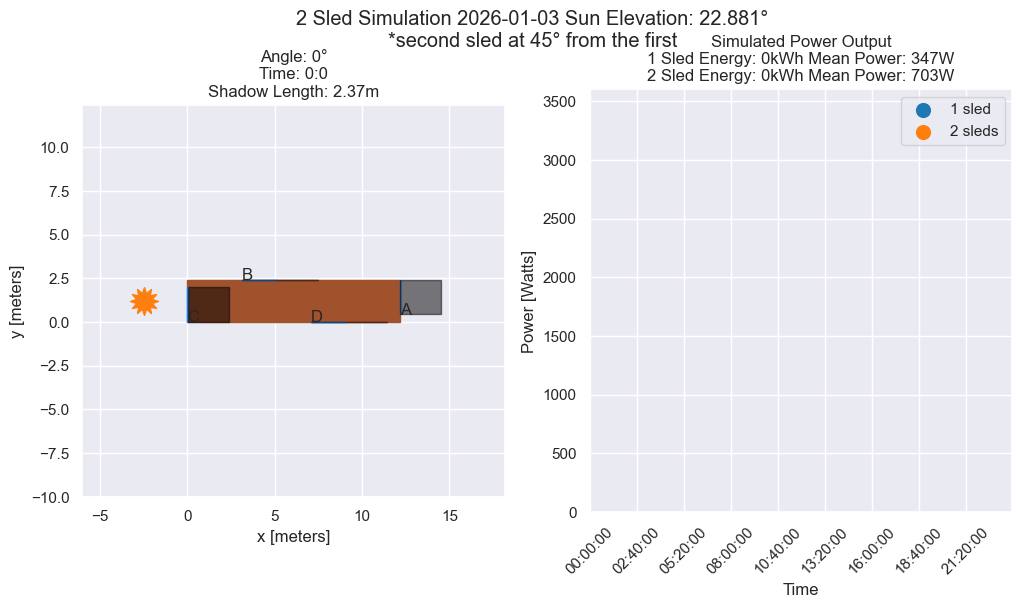

In [48]:
# This code will do the same things as the previous code, but it will simulate another sled at 45 degree tilt
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin
import seaborn as sns
import math
from VerticalModelFunction import model as VerticalModel
import datetime


# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'

effs = [0.24699832280882955,0.03850296370170911, 0.05890744297245301]

def serial_date_to_string(year,srl_no):
    '''
    This function turns a day number and year to human readable date. Stole from stack overflow with minor modifactions
    '''
    # This will only work for years in this millenium!
    year_2 = year+2000
    # we need to use a 2 digit year
    new_date = datetime.datetime(year_2,1,1,0,0) + datetime.timedelta(srl_no - 1)
    return new_date.strftime("%Y-%m-%d")


# import NOAA data function
def Import_NOAA_Data(year, day):
    input_1 = year
    input_2 = day
    # -----------------NOAA-----------------------------------
    NOAA = [] #list to hold dataframes
    for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
        iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
        filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
        # print(filename) #print the filename being accessed
    
        try:
            file = urllib.request.urlopen(filename)
            data = file.read().decode('utf-8').split('\n') #read the file and split into lines
            #convert data to dataframe
            df = pd.DataFrame([row.split() for row in data[2:]])
            # print(dt)
            NOAA.append(df) #append dataframe to list
        except urllib.error.HTTPError:
            print()
            # print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    NOAAdir_ir_1 = NOAA[0][12]
    NOAAdir_ir_2 = NOAA[1][12]
    NOAAtemp = NOAA[0][38]
    # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
    # print(f'NOAAtemp: {NOAAtemp}')
    # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
    # concatenate the two days data with time correction
    NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))

    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    # diffuse irradiance
    NOAAdiff_ir_1 = NOAA[0][14]
    NOAAdiff_ir_2 = NOAA[1][14]
    
    # concatenate the two days data with time correction
    NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    NOAAup_ir_1 = NOAA[0][10] 
    NOAAup_ir_2 = NOAA[1][10]
    NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDTup_ir = NZDTup_ir.astype(float)
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula

    '''Solar Zenith Angle'''
    NOAA_Zenith_1 = NOAA[0][7] 
    NOAA_Zenith_2 = NOAA[1][7]
    NZDT_Zenith= pd.concat([NOAA_Zenith_1.iloc[660:1440], NOAA_Zenith_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDT_Zenith = NZDT_Zenith.astype(float)
    #remove nan values from NZDTup_ir 
    NZDT_Zenith[NZDT_Zenith == -9999.9] = np.nan
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time, NZDT_Zenith


day = 3
year = 26

direct_irradiance, diffuse_irradiance, upwelling_irradiance, NOAA_time, solar_zenith = Import_NOAA_Data(year,day)

solar_azimuths = np.linspace(0,360, 10)

solar_zenith_mean = np.nanmean(solar_zenith)
print(solar_zenith_mean)

solar_elevation = 90 - solar_zenith_mean
print(solar_elevation)

panel_height = 1
panel_lift = 0
shadow_length = (panel_height+panel_lift)/np.tan(solar_elevation*np.pi/180)
print(shadow_length)
visual_panel_thickness = .03
panel_length = 2

sled_width = 12.192 
sled_height = 2.4384



# B_D_spacing_diff = (1/2)*(sled_width-((1/3)*(-1*sled_width+np.sqrt(sled_width**2+3*(sled_width**2-8*sled_height*panel_length+4*panel_length**2))))) - panel_length
B_D_spacing_diff = (1/3)*((-1)*np.sqrt(sled_width**2-4*sled_width*panel_length+7*panel_length**2-6*panel_length*sled_height)+2*sled_width-4*panel_length)
print(B_D_spacing_diff)

if shadow_length>B_D_spacing_diff:
    WarningMessage = 'WARNING: SHADING IS PRESENT\nSIMULATION UNTRUSTWORTHY'
else:
    WarningMessage = ''
print(WarningMessage)
    

# lets find the power output from VerticalModelFunction
angles = [0,90,180,270]
sim_powers = []
for a in angles:
    sim_power = VerticalModel(direct_irradiance, diffuse_irradiance, upwelling_irradiance, effs, 50, solar_zenith_mean, 360-a-90) #there was an error in defining my angle, mismatch the picuture and the model by 90, I correct it here
    sim_powers.append(sim_power)
total_power = np.array(sim_powers).sum(axis=0)
sim_A, sim_B, sim_C, sim_D = sim_powers

mean_power = np.nanmean(total_power)

# now add a second sled [8 panel total]
angles_8 = [0,45,90,135,180,225,270,315]
sim_powers_8 = []
for a in angles_8:
    sim_power_8 = VerticalModel(direct_irradiance, diffuse_irradiance, upwelling_irradiance, effs, 50, solar_zenith_mean, 360-a-90) #there was an error in defining my angle, mismatch the picuture and the model by 90, I correct it here
    sim_powers_8.append(sim_power_8)
total_power_8 = np.array(sim_powers_8).sum(axis=0)
# sim_A_4, sim_A8, sim_B_4, sim_B8, sim_C_4, sim_C8, sim_D_4, sim_D8 = sim_powers_8

mean_power_8 = np.nanmean(total_power_8)



fig, ax = plt.subplots(1,2,figsize = (12,6))

sled = plt.Rectangle((0, 0), width = sled_width, height = sled_height, facecolor = 'sienna', edgecolor = 'sienna')

A_pos = (sled_width - visual_panel_thickness, sled_height - panel_length)
B_pos = (0 + B_D_spacing_diff, sled_height - visual_panel_thickness)
C_pos = (0, 0)
D_pos = (sled_width - panel_length - B_D_spacing_diff, 0)




def animate(i):

    ax[1].cla()
    ax[1].set_xlim(0, 1440)
    ax[1].set_ylim(0, 1800*2)
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], total_power[0:int(i*1440/360)], s = 2, color = 'tab:blue', label = '1 sled')
    # ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_A[0:int(i*1440/360)], s = 2, color = 'tab:orange', label = 'A')
    # ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_B[0:int(i*1440/360)], s = 2, color = 'tab:green', label = 'B')
    # ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_C[0:int(i*1440/360)], s = 2, color = 'tab:red', label = 'C')
    # ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_D[0:int(i*1440/360)], s = 2, color = 'tab:purple', label = 'D')
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], total_power_8[0:int(i*1440/360)], s = 2, color = 'tab:orange', label = '2 sleds')
    ax[1].legend(markerscale = 7)
    # ax[1].set_aspect('equal')
    ax[1].set_box_aspect(1)
    energy = trapezoid(np.nan_to_num(total_power[0:int(i*1440/360)],nan = 0),dx=60)/(1000*60**2)
    ax[1].set_title(f'Simulated Power Output\nMean Power: {np.round(mean_power,1)}W\nEnergy:{np.round(energy,1)}kWh')
    
    energy_8 = trapezoid(np.nan_to_num(total_power_8[0:int(i*1440/360)],nan = 0),dx=60)/(1000*60**2)
    ax[1].set_title(f'Simulated Power Output\nMean Power: {np.round(mean_power_8,1)}W\nEnergy:{np.round(energy_8,1)}kWh')
    
    one_sled_osc_ammount = 100*(np.nanmax(total_power) - np.nanmin(total_power))/mean_power
    two_sled_osc_ammount = 100*(np.nanmax(total_power_8) - np.nanmin(total_power_8))/mean_power_8
    
    # ax[1].set_title(f'Simulated Power Output\n1 Sled Osciallation: {np.round(one_sled_osc_ammount,2)}%\n2 Sled Oscilation: {np.round(two_sled_osc_ammount,2)}%\n1 Sled Energy: {int(energy)} Mean Power: {int(mean_power)}\n2 Sled Energy: {int(energy_8)} Mean Power: {int(mean_power_8)}')
    ax[1].set_title(f'Simulated Power Output\n1 Sled Energy: {int(energy)}kWh Mean Power: {int(mean_power)}W\n2 Sled Energy: {int(energy_8)}kWh Mean Power: {int(mean_power_8)}W')
    
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Power [Watts]')
    ax[1].set_xticks(np.linspace(0,1440,1440)[::160],labels = NOAA_time[::160], rotation = 45)
    


    
    ax[0].cla()
    
    # xmin = -2*shadow_length
    # xmax = 2*shadow_length+sled_width
    # ymin = -4*shadow_length
    # ymax = 4*shadow_length+sled_height
    xmin = -6
    xmax = sled_width+6
    ymin = -10
    ymax = sled_height+10
    ax[0].set_xlim(xmin,xmax)
    ax[0].set_ylim(ymin,ymax)
    ax[0].set_xlabel('x [meters]')
    ax[0].set_ylabel('y [meters]')
    solar_azimuth = i
    # lengths in meters

    
    panel_A = plt.Rectangle(A_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_B = plt.Rectangle(B_pos, width = panel_length, height = visual_panel_thickness, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_C = plt.Rectangle(C_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_D = plt.Rectangle(D_pos, width = panel_length, height = visual_panel_thickness, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    
    ax[0].add_patch(sled)
    ax[0].add_patch(panel_A)
    ax[0].add_patch(panel_B)
    ax[0].add_patch(panel_C)
    ax[0].add_patch(panel_D)

    solar_azimuth = solar_azimuth*np.pi/180  #enter in degrees
    
    
    
    A_shadow_points = [(A_pos[0]+visual_panel_thickness/2,A_pos[1]),(A_pos[0]+visual_panel_thickness/2,A_pos[1]+panel_length),(A_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),A_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(A_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),A_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_A = Polygon(A_shadow_points, color = 'black', alpha = .5)
    
    
    B_shadow_points = [(B_pos[0],visual_panel_thickness/2+B_pos[1]),(B_pos[0]+panel_length,visual_panel_thickness/2+B_pos[1]),(B_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+B_pos[1]+ shadow_length*np.sin(solar_azimuth)),(B_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+B_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_B = Polygon(B_shadow_points, color = 'black', alpha = .5)
    
    
    C_shadow_points = [(C_pos[0]+visual_panel_thickness/2,C_pos[1]),(C_pos[0]+visual_panel_thickness/2,C_pos[1]+panel_length),(C_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),C_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(C_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),C_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_C = Polygon(C_shadow_points, color = 'black', alpha = .5)
    
    
    D_shadow_points = [(D_pos[0],visual_panel_thickness/2+D_pos[1]),(D_pos[0]+panel_length,visual_panel_thickness/2+D_pos[1]),(D_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+D_pos[1]+ shadow_length*np.sin(solar_azimuth)),(D_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+D_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_D = Polygon(D_shadow_points, color = 'black', alpha = .5)


    ax[0].add_patch(shadow_A)
    ax[0].add_patch(shadow_B)
    ax[0].add_patch(shadow_C)
    ax[0].add_patch(shadow_D)

    ax[0].text(A_pos[0], A_pos[1], 'A')
    ax[0].text(B_pos[0], B_pos[1], 'B')
    ax[0].text(C_pos[0], C_pos[1], 'C')
    ax[0].text(D_pos[0], D_pos[1], 'D')
    # ax[0].text(sled_width/3,sled_height/3,'x2', fontsize = 15, color = 'beige')
    # ax[0].text(sled_width/2,sled_height/2,f'{i}°', fontsize = 10, color = 'beige')
    # ax[0].text(sled_width/2,sled_height/4,f'{math.floor(i/15)}:{math.floor((np.round(i/15,2)-math.floor(i/15))*60)}', fontsize = 10, color = 'beige')
    sns.set_theme(style = 'darkgrid')
    ax[0].set_title(f'Angle: {i}°\nTime: {math.floor(i/15)}:{math.floor((np.round(i/15,2)-math.floor(i/15))*60)}\nShadow Length: {np.round(shadow_length, 2)}m')
    ax[0].set_aspect('equal')
    ax[0].text(xmin/2,ymin/2,WarningMessage)

    
    # lets put a ☀️ where the sun is 
    cartoon_solar_distance = 1*shadow_length+np.sqrt(.25*(sled_width**2+sled_height**2))
    ax[0].plot(sled_width/2+cartoon_solar_distance*np.cos((180+i)*np.pi/180),sled_height/2+cartoon_solar_distance*np.sin((180+i)*np.pi/180), marker = "$\u2739$", color = 'tab:orange', markersize = 20)
    
    Date = serial_date_to_string(year, day)
    plt.suptitle(f'2 Sled Simulation {Date} Sun Elevation: {np.round(solar_elevation,3)}°\n*second sled at 45° from the first')
    # ax = plt.gca()

    
    # return shadow_A, shadow_B, shadow_C, shadow_D
    # ax.add_patch(shadow_A_2)
    # ax.add_patch(shadow_B_1)
    # ax.add_patch(shadow_B_2)
    # ax.add_patch(shadow_C_1)
    # ax.add_patch(shadow_C_2)
    # ax.add_patch(shadow_D_1)
    # ax.add_patch(shadow_D_2)





# ax.text(-1,-1, f'{sled_width}m', size=20)

# plt.axis('scaled')
# plt.show()
ani = animation.FuncAnimation(
    fig, animate, interval=1, blit=False, frames = 360)
writer = animation.PillowWriter(fps=15,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
ani.save(f'SledArrayDesignes/DoubleSledArray_{year}_{day}.gif', writer=writer)






66.96952083333335
23.03047916666665
2.3523723553853015
3.1078946199231496



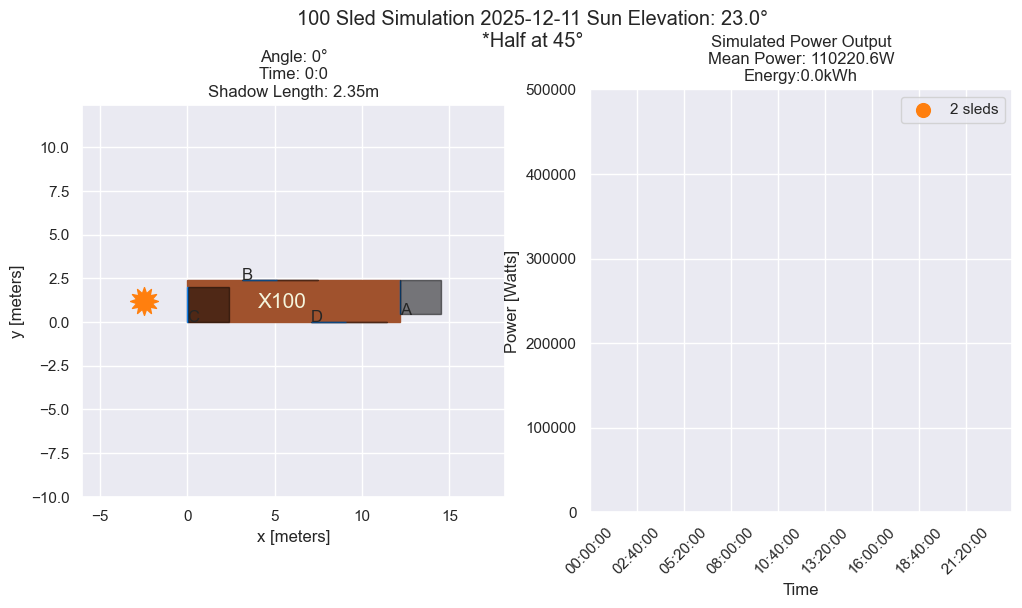

In [23]:
# this will simulate N sleds, half with 45 degree tilt
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin
import seaborn as sns
import math
from VerticalModelFunction import model as VerticalModel
import datetime


# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'

effs = [0.24699832280882955,0.05706853042746707, 0.05706853042746707]

def serial_date_to_string(year,srl_no):
    '''
    This function turns a day number and year to human readable date. Stole from stack overflow with minor modifactions
    '''
    # This will only work for years in this millenium!
    year_2 = year+2000
    # we need to use a 2 digit year
    new_date = datetime.datetime(year_2,1,1,0,0) + datetime.timedelta(srl_no - 1)
    return new_date.strftime("%Y-%m-%d")


# import NOAA data function
def Import_NOAA_Data(year, day):
    input_1 = year
    input_2 = day
    # -----------------NOAA-----------------------------------
    NOAA = [] #list to hold dataframes
    for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
        iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
        filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
        # print(filename) #print the filename being accessed
    
        try:
            file = urllib.request.urlopen(filename)
            data = file.read().decode('utf-8').split('\n') #read the file and split into lines
            #convert data to dataframe
            df = pd.DataFrame([row.split() for row in data[2:]])
            # print(dt)
            NOAA.append(df) #append dataframe to list
        except urllib.error.HTTPError:
            print()
            # print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    NOAAdir_ir_1 = NOAA[0][12]
    NOAAdir_ir_2 = NOAA[1][12]
    NOAAtemp = NOAA[0][38]
    # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
    # print(f'NOAAtemp: {NOAAtemp}')
    # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
    # concatenate the two days data with time correction
    NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))

    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    # diffuse irradiance
    NOAAdiff_ir_1 = NOAA[0][14]
    NOAAdiff_ir_2 = NOAA[1][14]
    
    # concatenate the two days data with time correction
    NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    NOAAup_ir_1 = NOAA[0][10] 
    NOAAup_ir_2 = NOAA[1][10]
    NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDTup_ir = NZDTup_ir.astype(float)
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula

    '''Solar Zenith Angle'''
    NOAA_Zenith_1 = NOAA[0][7] 
    NOAA_Zenith_2 = NOAA[1][7]
    NZDT_Zenith= pd.concat([NOAA_Zenith_1.iloc[660:1440], NOAA_Zenith_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDT_Zenith = NZDT_Zenith.astype(float)
    #remove nan values from NZDTup_ir 
    NZDT_Zenith[NZDT_Zenith == -9999.9] = np.nan
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time, NZDT_Zenith


day = 345
year = 25
number_of_sleds = 100

direct_irradiance, diffuse_irradiance, upwelling_irradiance, NOAA_time, solar_zenith = Import_NOAA_Data(year,day)

solar_azimuths = np.linspace(0,360, 10)

solar_zenith_mean = np.nanmean(solar_zenith)
print(solar_zenith_mean)

solar_elevation = 90 - solar_zenith_mean
print(solar_elevation)

panel_height = 1
panel_lift = 0
shadow_length = (panel_height+panel_lift)/np.tan(solar_elevation*np.pi/180)
print(shadow_length)
visual_panel_thickness = .03
panel_length = 2

sled_width = 12.192 
sled_height = 2.4384



# B_D_spacing_diff = (1/2)*(sled_width-((1/3)*(-1*sled_width+np.sqrt(sled_width**2+3*(sled_width**2-8*sled_height*panel_length+4*panel_length**2))))) - panel_length
B_D_spacing_diff = (1/3)*((-1)*np.sqrt(sled_width**2-4*sled_width*panel_length+7*panel_length**2-6*panel_length*sled_height)+2*sled_width-4*panel_length)
print(B_D_spacing_diff)

if shadow_length>B_D_spacing_diff:
    WarningMessage = 'WARNING: SHADING IS PRESENT\nSIMULATION UNTRUSTWORTHY'
else:
    WarningMessage = ''
print(WarningMessage)
    

# lets find the power output from VerticalModelFunction
angles = [0,90,180,270]
sim_powers = []
for a in angles:
    sim_power = VerticalModel(direct_irradiance, diffuse_irradiance, upwelling_irradiance, effs, 50, solar_zenith_mean, 360-a-90) #there was an error in defining my angle, mismatch the picuture and the model by 90, I correct it here
    sim_powers.append(sim_power*number_of_sleds/2)
total_power = np.array(sim_powers).sum(axis=0)
sim_A, sim_B, sim_C, sim_D = sim_powers

mean_power = np.nanmean(total_power)

# now add a second sled [8 panel total]
angles_8 = [0,45,90,135,180,225,270,315]
sim_powers_8 = []
for a in angles_8:
    sim_power_8 = VerticalModel(direct_irradiance, diffuse_irradiance, upwelling_irradiance, effs, 50, solar_zenith_mean, 360-a-90) #there was an error in defining my angle, mismatch the picuture and the model by 90, I correct it here
    sim_powers_8.append(sim_power_8*number_of_sleds/2)
total_power_8 = np.array(sim_powers_8).sum(axis=0)
# sim_A_4, sim_A8, sim_B_4, sim_B8, sim_C_4, sim_C8, sim_D_4, sim_D8 = sim_powers_8

mean_power_8 = np.nanmean(total_power_8)



fig, ax = plt.subplots(1,2,figsize = (12,6))

sled = plt.Rectangle((0, 0), width = sled_width, height = sled_height, facecolor = 'sienna', edgecolor = 'sienna')

A_pos = (sled_width - visual_panel_thickness, sled_height - panel_length)
B_pos = (0 + B_D_spacing_diff, sled_height - visual_panel_thickness)
C_pos = (0, 0)
D_pos = (sled_width - panel_length - B_D_spacing_diff, 0)




def animate(i):

    ax[1].cla()
    ax[1].set_xlim(0, 1440)
    ax[1].set_ylim(0,1000000/2)
    # ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], total_power[0:int(i*1440/360)], s = 2, color = 'tab:blue', label = '1 sled')
    # ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_A[0:int(i*1440/360)], s = 2, color = 'tab:orange', label = 'A')
    # ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_B[0:int(i*1440/360)], s = 2, color = 'tab:green', label = 'B')
    # ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_C[0:int(i*1440/360)], s = 2, color = 'tab:red', label = 'C')
    # ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_D[0:int(i*1440/360)], s = 2, color = 'tab:purple', label = 'D')
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], total_power_8[0:int(i*1440/360)], s = 2, color = 'tab:orange', label = '2 sleds')
    ax[1].legend(markerscale = 7)
    # ax[1].set_aspect('equal')
    ax[1].set_box_aspect(1)
    energy = trapezoid(np.nan_to_num(total_power[0:int(i*1440/360)],nan = 0),dx=60)/(1000*60**2)
    # ax[1].set_title(f'Simulated Power Output\nMean Power: {np.round(mean_power,1)}W\nEnergy:{np.round(energy,1)}kWh')
    
    energy_8 = trapezoid(np.nan_to_num(total_power_8[0:int(i*1440/360)],nan = 0),dx=60)/(1000*60**2)
    ax[1].set_title(f'Simulated Power Output\nMean Power: {np.round(mean_power_8,1)}W\nEnergy:{np.round(energy_8,1)}kWh')
    # energy = trapezoid(np.nan_to_num(total_power[0:int(i*1440/360)],nan = 0),dx=60)/(1000*60**2)
    # ax[1].set_title(f'Simulated Power Output\nMean Power: {np.round(mean_power,1)}W\nEnergy:{np.round(energy,1)}kWh')
    # energy_8 = trapezoid(np.nan_to_num(total_power_8[0:int(i*1440/360)],nan = 0),dx=60)/(1000*60**2)
    # one_sled_osc_ammount = 100*(np.nanmax(total_power) - np.nanmin(total_power))/mean_power
    # two_sled_osc_ammount = 100*(np.nanmax(total_power_8) - np.nanmin(total_power_8))/mean_power_8
    
    # ax[1].set_title(f'Simulated Power Output\n1 Sled Osciallation: {np.round(one_sled_osc_ammount,2)}%\n2 Sled Oscilation: {np.round(two_sled_osc_ammount,2)}%')
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Power [Watts]')
    ax[1].set_xticks(np.linspace(0,1440,1440)[::160],labels = NOAA_time[::160], rotation = 45)
    


    
    ax[0].cla()
    
    # xmin = -2*shadow_length
    # xmax = 2*shadow_length+sled_width
    # ymin = -4*shadow_length
    # ymax = 4*shadow_length+sled_height
    xmin = -6
    xmax = sled_width+6
    ymin = -10
    ymax = sled_height+10
    ax[0].set_xlim(xmin,xmax)
    ax[0].set_ylim(ymin,ymax)
    ax[0].set_xlabel('x [meters]')
    ax[0].set_ylabel('y [meters]')
    solar_azimuth = i
    # lengths in meters

    
    panel_A = plt.Rectangle(A_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_B = plt.Rectangle(B_pos, width = panel_length, height = visual_panel_thickness, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_C = plt.Rectangle(C_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_D = plt.Rectangle(D_pos, width = panel_length, height = visual_panel_thickness, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    
    ax[0].add_patch(sled)
    ax[0].add_patch(panel_A)
    ax[0].add_patch(panel_B)
    ax[0].add_patch(panel_C)
    ax[0].add_patch(panel_D)

    solar_azimuth = solar_azimuth*np.pi/180  #enter in degrees
    
    
    
    A_shadow_points = [(A_pos[0]+visual_panel_thickness/2,A_pos[1]),(A_pos[0]+visual_panel_thickness/2,A_pos[1]+panel_length),(A_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),A_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(A_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),A_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_A = Polygon(A_shadow_points, color = 'black', alpha = .5)
    
    
    B_shadow_points = [(B_pos[0],visual_panel_thickness/2+B_pos[1]),(B_pos[0]+panel_length,visual_panel_thickness/2+B_pos[1]),(B_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+B_pos[1]+ shadow_length*np.sin(solar_azimuth)),(B_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+B_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_B = Polygon(B_shadow_points, color = 'black', alpha = .5)
    
    
    C_shadow_points = [(C_pos[0]+visual_panel_thickness/2,C_pos[1]),(C_pos[0]+visual_panel_thickness/2,C_pos[1]+panel_length),(C_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),C_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(C_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),C_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_C = Polygon(C_shadow_points, color = 'black', alpha = .5)
    
    
    D_shadow_points = [(D_pos[0],visual_panel_thickness/2+D_pos[1]),(D_pos[0]+panel_length,visual_panel_thickness/2+D_pos[1]),(D_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+D_pos[1]+ shadow_length*np.sin(solar_azimuth)),(D_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+D_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_D = Polygon(D_shadow_points, color = 'black', alpha = .5)


    ax[0].add_patch(shadow_A)
    ax[0].add_patch(shadow_B)
    ax[0].add_patch(shadow_C)
    ax[0].add_patch(shadow_D)

    ax[0].text(A_pos[0], A_pos[1], 'A')
    ax[0].text(B_pos[0], B_pos[1], 'B')
    ax[0].text(C_pos[0], C_pos[1], 'C')
    ax[0].text(D_pos[0], D_pos[1], 'D')
    ax[0].text(sled_width/3,sled_height/3,f'X{int(number_of_sleds)}', fontsize = 15, color = 'beige')
    # ax[0].text(sled_width/2,sled_height/2,f'{i}°', fontsize = 10, color = 'beige')
    # ax[0].text(sled_width/2,sled_height/4,f'{math.floor(i/15)}:{math.floor((np.round(i/15,2)-math.floor(i/15))*60)}', fontsize = 10, color = 'beige')
    sns.set_theme(style = 'darkgrid')
    ax[0].set_title(f'Angle: {i}°\nTime: {math.floor(i/15)}:{math.floor((np.round(i/15,2)-math.floor(i/15))*60)}\nShadow Length: {np.round(shadow_length, 2)}m')
    ax[0].set_aspect('equal')
    ax[0].text(xmin/2,ymin/2,WarningMessage)

    
    # lets put a ☀️ where the sun is 
    cartoon_solar_distance = 1*shadow_length+np.sqrt(.25*(sled_width**2+sled_height**2))
    ax[0].plot(sled_width/2+cartoon_solar_distance*np.cos((180+i)*np.pi/180),sled_height/2+cartoon_solar_distance*np.sin((180+i)*np.pi/180), marker = "$\u2739$", color = 'tab:orange', markersize = 20)
    
    Date = serial_date_to_string(year, day)
    plt.suptitle(f'{number_of_sleds} Sled Simulation {Date} Sun Elevation: {np.round(solar_elevation,1)}°\n*Half at 45°')
    # ax = plt.gca()

    
    # return shadow_A, shadow_B, shadow_C, shadow_D
    # ax.add_patch(shadow_A_2)
    # ax.add_patch(shadow_B_1)
    # ax.add_patch(shadow_B_2)
    # ax.add_patch(shadow_C_1)
    # ax.add_patch(shadow_C_2)
    # ax.add_patch(shadow_D_1)
    # ax.add_patch(shadow_D_2)





# ax.text(-1,-1, f'{sled_width}m', size=20)

# plt.axis('scaled')
# plt.show()
ani = animation.FuncAnimation(
    fig, animate, interval=1, blit=False, frames = 360)
writer = animation.PillowWriter(fps=15,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
ani.save(f'SledArrayDesignes/PairSledArray_{number_of_sleds}_{year}_{day}.gif', writer=writer)






66.96952083333335
23.03047916666665
2.3523723553853015
3.1078946199231496



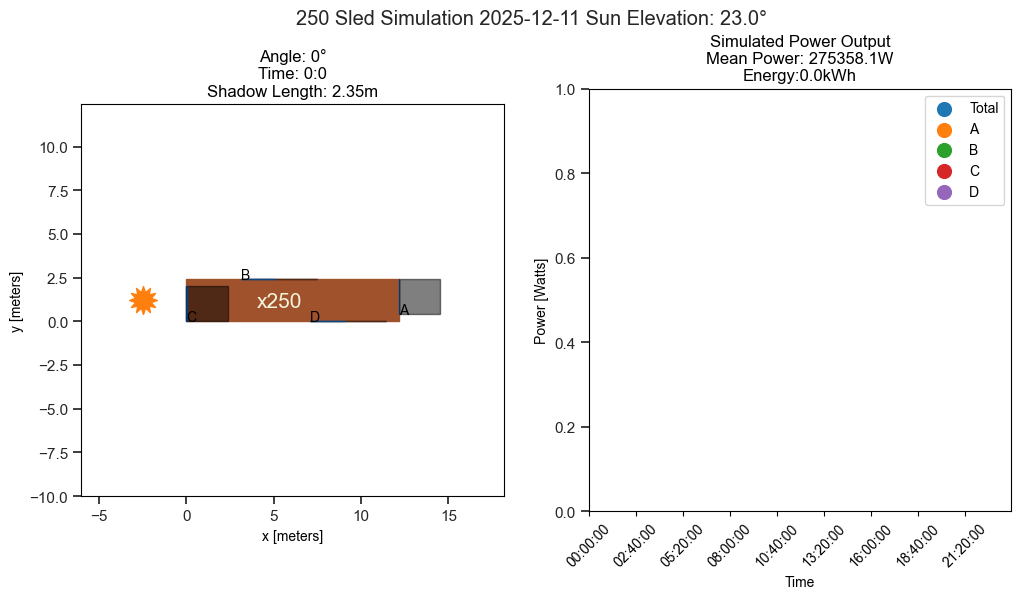

In [2]:
# This will be the same as the single sled, however we will N sleds. All of them in the same direction
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin
import seaborn as sns
import math
from VerticalModelFunction import model as VerticalModel
import datetime


# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'



def serial_date_to_string(year,srl_no):
    '''
    This function turns a day number and year to human readable date. Stole from stack overflow with minor modifactions
    '''
    # This will only work for years in this millenium!
    year_2 = year+2000
    # we need to use a 2 digit year
    new_date = datetime.datetime(year_2,1,1,0,0) + datetime.timedelta(srl_no - 1)
    return new_date.strftime("%Y-%m-%d")


# import NOAA data function
def Import_NOAA_Data(year, day):
    input_1 = year
    input_2 = day
    # -----------------NOAA-----------------------------------
    NOAA = [] #list to hold dataframes
    for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
        iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
        filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
        # print(filename) #print the filename being accessed
    
        try:
            file = urllib.request.urlopen(filename)
            data = file.read().decode('utf-8').split('\n') #read the file and split into lines
            #convert data to dataframe
            df = pd.DataFrame([row.split() for row in data[2:]])
            # print(dt)
            NOAA.append(df) #append dataframe to list
        except urllib.error.HTTPError:
            print()
            # print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    NOAAdir_ir_1 = NOAA[0][12]
    NOAAdir_ir_2 = NOAA[1][12]
    NOAAtemp = NOAA[0][38]
    # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
    # print(f'NOAAtemp: {NOAAtemp}')
    # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
    # concatenate the two days data with time correction
    NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))

    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    # diffuse irradiance
    NOAAdiff_ir_1 = NOAA[0][14]
    NOAAdiff_ir_2 = NOAA[1][14]
    
    # concatenate the two days data with time correction
    NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    NOAAup_ir_1 = NOAA[0][10] 
    NOAAup_ir_2 = NOAA[1][10]
    NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDTup_ir = NZDTup_ir.astype(float)
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula

    '''Solar Zenith Angle'''
    NOAA_Zenith_1 = NOAA[0][7] 
    NOAA_Zenith_2 = NOAA[1][7]
    NZDT_Zenith= pd.concat([NOAA_Zenith_1.iloc[660:1440], NOAA_Zenith_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDT_Zenith = NZDT_Zenith.astype(float)
    #remove nan values from NZDTup_ir 
    NZDT_Zenith[NZDT_Zenith == -9999.9] = np.nan
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time, NZDT_Zenith


day = 345
year = 25
number_of_sleds = 250
direct_irradiance, diffuse_irradiance, upwelling_irradiance, NOAA_time, solar_zenith = Import_NOAA_Data(year,day)

solar_azimuths = np.linspace(0,360, 10)

solar_zenith_mean = np.nanmean(solar_zenith)
print(solar_zenith_mean)

solar_elevation = 90 - solar_zenith_mean
print(solar_elevation)

panel_height = 1
panel_lift = 0
shadow_length = (panel_height+panel_lift)/np.tan(solar_elevation*np.pi/180)
print(shadow_length)
visual_panel_thickness = .03
panel_length = 2

sled_width = 12.192 
sled_height = 2.4384



# B_D_spacing_diff = (1/2)*(sled_width-((1/3)*(-1*sled_width+np.sqrt(sled_width**2+3*(sled_width**2-8*sled_height*panel_length+4*panel_length**2))))) - panel_length
B_D_spacing_diff = (1/3)*((-1)*np.sqrt(sled_width**2-4*sled_width*panel_length+7*panel_length**2-6*panel_length*sled_height)+2*sled_width-4*panel_length)
print(B_D_spacing_diff)

if shadow_length>B_D_spacing_diff:
    WarningMessage = 'WARNING: SHADING IS PRESENT\nSIMULATION UNTRUSTWORTHY'
else:
    WarningMessage = ''
print(WarningMessage)
    

# lets find the power output from VerticalModelFunction

angles = [0,90,180,270]

sim_powers = []
for a in angles:
    sim_power = VerticalModel(direct_irradiance, diffuse_irradiance, upwelling_irradiance, [.22,.08,.08], 50, solar_zenith_mean, 360-a-90) #there was an error in defining my angle, mismatch the picuture and the model by 90, I correct it here
    sim_powers.append(sim_power*number_of_sleds)
total_power = np.array(sim_powers).sum(axis=0)
sim_A, sim_B, sim_C, sim_D = sim_powers

mean_power = np.nanmean(total_power)





fig, ax = plt.subplots(1,2,figsize = (12,6))

sled = plt.Rectangle((0, 0), width = sled_width, height = sled_height, facecolor = 'sienna', edgecolor = 'sienna')

A_pos = (sled_width - visual_panel_thickness, sled_height - panel_length)
B_pos = (0 + B_D_spacing_diff, sled_height - visual_panel_thickness)
C_pos = (0, 0)
D_pos = (sled_width - panel_length - B_D_spacing_diff, 0)




def animate(i):

    ax[1].cla()
    ax[1].set_xlim(0, 1440)
    ax[1].set_ylim(0)
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], total_power[0:int(i*1440/360)], s = 2, color = 'tab:blue', label = 'Total')
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_A[0:int(i*1440/360)], s = 2, color = 'tab:orange', label = 'A')
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_B[0:int(i*1440/360)], s = 2, color = 'tab:green', label = 'B')
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_C[0:int(i*1440/360)], s = 2, color = 'tab:red', label = 'C')
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_D[0:int(i*1440/360)], s = 2, color = 'tab:purple', label = 'D')
    ax[1].legend(markerscale = 7)
    # ax[1].set_aspect('equal')
    ax[1].set_box_aspect(1)
    energy = trapezoid(np.nan_to_num(total_power[0:int(i*1440/360)],nan = 0),dx=60)/(1000*60**2)
    ax[1].set_title(f'Simulated Power Output\nMean Power: {np.round(mean_power,1)}W\nEnergy:{np.round(energy,1)}kWh')
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Power [Watts]')
    ax[1].set_xticks(np.linspace(0,1440,1440)[::160],labels = NOAA_time[::160], rotation = 45)
    


    
    ax[0].cla()
    
    # xmin = -2*shadow_length
    # xmax = 2*shadow_length+sled_width
    # ymin = -4*shadow_length
    # ymax = 4*shadow_length+sled_height
    xmin = -6
    xmax = sled_width+6
    ymin = -10
    ymax = sled_height+10
    ax[0].set_xlim(xmin,xmax)
    ax[0].set_ylim(ymin,ymax)
    ax[0].set_xlabel('x [meters]')
    ax[0].set_ylabel('y [meters]')
    solar_azimuth = i
    # lengths in meters

    
    panel_A = plt.Rectangle(A_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_B = plt.Rectangle(B_pos, width = panel_length, height = visual_panel_thickness, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_C = plt.Rectangle(C_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_D = plt.Rectangle(D_pos, width = panel_length, height = visual_panel_thickness, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    
    ax[0].add_patch(sled)
    ax[0].add_patch(panel_A)
    ax[0].add_patch(panel_B)
    ax[0].add_patch(panel_C)
    ax[0].add_patch(panel_D)

    solar_azimuth = solar_azimuth*np.pi/180  #enter in degrees
    
    
    
    A_shadow_points = [(A_pos[0]+visual_panel_thickness/2,A_pos[1]),(A_pos[0]+visual_panel_thickness/2,A_pos[1]+panel_length),(A_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),A_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(A_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),A_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_A = Polygon(A_shadow_points, color = 'black', alpha = .5)
    
    
    B_shadow_points = [(B_pos[0],visual_panel_thickness/2+B_pos[1]),(B_pos[0]+panel_length,visual_panel_thickness/2+B_pos[1]),(B_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+B_pos[1]+ shadow_length*np.sin(solar_azimuth)),(B_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+B_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_B = Polygon(B_shadow_points, color = 'black', alpha = .5)
    
    
    C_shadow_points = [(C_pos[0]+visual_panel_thickness/2,C_pos[1]),(C_pos[0]+visual_panel_thickness/2,C_pos[1]+panel_length),(C_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),C_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(C_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),C_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_C = Polygon(C_shadow_points, color = 'black', alpha = .5)
    
    
    D_shadow_points = [(D_pos[0],visual_panel_thickness/2+D_pos[1]),(D_pos[0]+panel_length,visual_panel_thickness/2+D_pos[1]),(D_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+D_pos[1]+ shadow_length*np.sin(solar_azimuth)),(D_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+D_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_D = Polygon(D_shadow_points, color = 'black', alpha = .5)


    ax[0].add_patch(shadow_A)
    ax[0].add_patch(shadow_B)
    ax[0].add_patch(shadow_C)
    ax[0].add_patch(shadow_D)

    ax[0].text(A_pos[0], A_pos[1], 'A')
    ax[0].text(B_pos[0], B_pos[1], 'B')
    ax[0].text(C_pos[0], C_pos[1], 'C')
    ax[0].text(D_pos[0], D_pos[1], 'D')
    ax[0].text(sled_width/3,sled_height/3,f'x{number_of_sleds}', fontsize = 15, color = 'beige')
    # ax[0].text(sled_width/2,sled_height/2,f'{i}°', fontsize = 10, color = 'beige')
    # ax[0].text(sled_width/2,sled_height/4,f'{math.floor(i/15)}:{math.floor((np.round(i/15,2)-math.floor(i/15))*60)}', fontsize = 10, color = 'beige')
    sns.set_theme(style = 'darkgrid')
    ax[0].set_title(f'Angle: {i}°\nTime: {math.floor(i/15)}:{math.floor((np.round(i/15,2)-math.floor(i/15))*60)}\nShadow Length: {np.round(shadow_length, 2)}m')
    ax[0].set_aspect('equal')
    ax[0].text(xmin/2,ymin/2,WarningMessage)

    
    # lets put a ☀️ where the sun is 
    cartoon_solar_distance = 1*shadow_length+np.sqrt(.25*(sled_width**2+sled_height**2))
    ax[0].plot(sled_width/2+cartoon_solar_distance*np.cos((180+i)*np.pi/180),sled_height/2+cartoon_solar_distance*np.sin((180+i)*np.pi/180), marker = "$\u2739$", color = 'tab:orange', markersize = 20)
    
    Date = serial_date_to_string(year, day)
    plt.suptitle(f'{number_of_sleds} Sled Simulation {Date} Sun Elevation: {np.round(solar_elevation,1)}°')
    # ax = plt.gca()

    
    # return shadow_A, shadow_B, shadow_C, shadow_D
    # ax.add_patch(shadow_A_2)
    # ax.add_patch(shadow_B_1)
    # ax.add_patch(shadow_B_2)
    # ax.add_patch(shadow_C_1)
    # ax.add_patch(shadow_C_2)
    # ax.add_patch(shadow_D_1)
    # ax.add_patch(shadow_D_2)





# ax.text(-1,-1, f'{sled_width}m', size=20)

# plt.axis('scaled')
# plt.show()
ani = animation.FuncAnimation(
    fig, animate, interval=1, blit=False, frames = 360)
writer = animation.PillowWriter(fps=15,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
ani.save(f'SledArrayDesignes/SledArray_{number_of_sleds}_{year}_{day}.gif', writer=writer)






66.96952083333335
23.03047916666665
2.3523723553853015
3.1078946199231496
NO SHADING


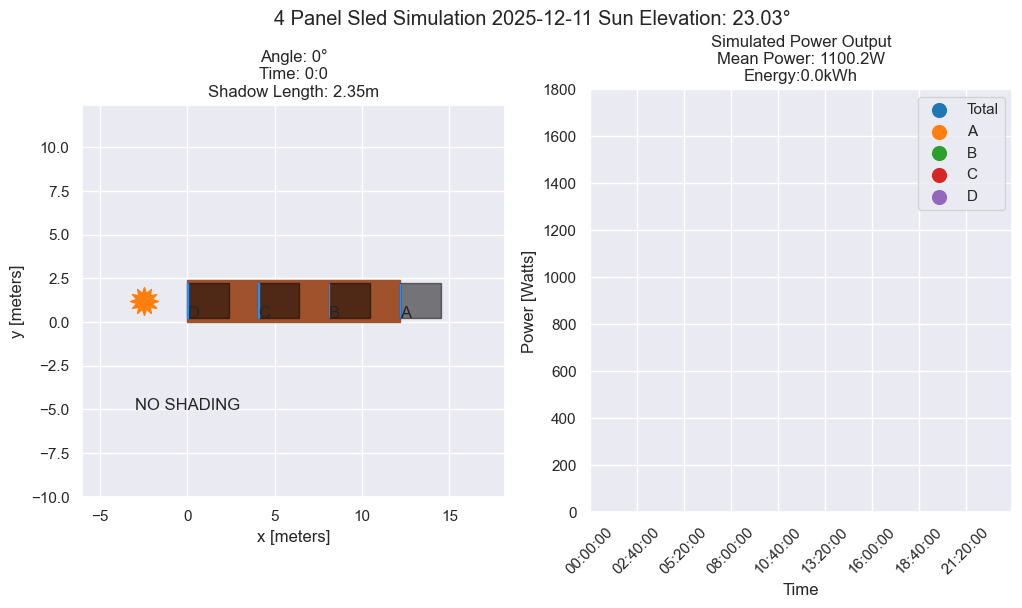

In [45]:
# 4 sled Carsten
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin
import seaborn as sns
import math
from VerticalModelFunction import model as VerticalModel
import datetime


# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'

effs= [0.24699832280882955,0.03850296370170911, 0.05890744297245301]

def serial_date_to_string(year,srl_no):
    '''
    This function turns a day number and year to human readable date. Stole from stack overflow with minor modifactions
    '''
    # This will only work for years in this millenium!
    year_2 = year+2000
    # we need to use a 2 digit year
    new_date = datetime.datetime(year_2,1,1,0,0) + datetime.timedelta(srl_no - 1)
    return new_date.strftime("%Y-%m-%d")


# import NOAA data function
def Import_NOAA_Data(year, day):
    input_1 = year
    input_2 = day
    # -----------------NOAA-----------------------------------
    NOAA = [] #list to hold dataframes
    for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
        iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
        filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
        # print(filename) #print the filename being accessed
    
        try:
            file = urllib.request.urlopen(filename)
            data = file.read().decode('utf-8').split('\n') #read the file and split into lines
            #convert data to dataframe
            df = pd.DataFrame([row.split() for row in data[2:]])
            # print(dt)
            NOAA.append(df) #append dataframe to list
        except urllib.error.HTTPError:
            print()
            # print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    NOAAdir_ir_1 = NOAA[0][12]
    NOAAdir_ir_2 = NOAA[1][12]
    NOAAtemp = NOAA[0][38]
    # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
    # print(f'NOAAtemp: {NOAAtemp}')
    # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
    # concatenate the two days data with time correction
    NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))

    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    # diffuse irradiance
    NOAAdiff_ir_1 = NOAA[0][14]
    NOAAdiff_ir_2 = NOAA[1][14]
    
    # concatenate the two days data with time correction
    NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    NOAAup_ir_1 = NOAA[0][10] 
    NOAAup_ir_2 = NOAA[1][10]
    NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDTup_ir = NZDTup_ir.astype(float)
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula

    '''Solar Zenith Angle'''
    NOAA_Zenith_1 = NOAA[0][7] 
    NOAA_Zenith_2 = NOAA[1][7]
    NZDT_Zenith= pd.concat([NOAA_Zenith_1.iloc[660:1440], NOAA_Zenith_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDT_Zenith = NZDT_Zenith.astype(float)
    #remove nan values from NZDTup_ir 
    NZDT_Zenith[NZDT_Zenith == -9999.9] = np.nan
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time, NZDT_Zenith


day = 345
year = 25

direct_irradiance, diffuse_irradiance, upwelling_irradiance, NOAA_time, solar_zenith = Import_NOAA_Data(year,day)

solar_azimuths = np.linspace(0,360, 10)

solar_zenith_mean = np.nanmean(solar_zenith)
print(solar_zenith_mean)

solar_elevation = 90 - solar_zenith_mean
print(solar_elevation)

panel_height = 1
panel_lift = 0
shadow_length = (panel_height+panel_lift)/np.tan(solar_elevation*np.pi/180)
print(shadow_length)
visual_panel_thickness = .03
panel_length = 2

sled_width = 12.192 
sled_height = 2.4384



# B_D_spacing_diff = (1/2)*(sled_width-((1/3)*(-1*sled_width+np.sqrt(sled_width**2+3*(sled_width**2-8*sled_height*panel_length+4*panel_length**2))))) - panel_length
B_D_spacing_diff = (1/3)*((-1)*np.sqrt(sled_width**2-4*sled_width*panel_length+7*panel_length**2-6*panel_length*sled_height)+2*sled_width-4*panel_length)
print(B_D_spacing_diff)

panel_spacing = sled_width/3-2*visual_panel_thickness
if shadow_length>panel_spacing:
    WarningMessage = 'SHADING'
else:
    WarningMessage = 'NO SHADING'
print(WarningMessage)
    

# lets find the power output from VerticalModelFunction

angles = [0,0,0,0]

sim_powers = []
for a in angles:
    sim_power = VerticalModel(direct_irradiance, diffuse_irradiance, upwelling_irradiance, effs, 50, solar_zenith_mean, 360-a-90) #there was an error in defining my angle, mismatch the picuture and the model by 90, I correct it here
    sim_powers.append(sim_power)
total_power = np.array(sim_powers).sum(axis=0)
sim_A, sim_B, sim_C, sim_D = sim_powers

mean_power = np.nanmean(total_power)





fig, ax = plt.subplots(1,2,figsize = (12,6))

sled = plt.Rectangle((0, 0), width = sled_width, height = sled_height, facecolor = 'sienna', edgecolor = 'sienna')

A_pos = (sled_width-visual_panel_thickness, (sled_height-panel_length)/2)
B_pos = ((2/3)*sled_width - visual_panel_thickness, (sled_height-panel_length)/2)
C_pos = ((1/3)*sled_width - visual_panel_thickness/2, (sled_height-panel_length)/2)
D_pos = (0, (sled_height-panel_length)/2)




def animate(i):

    ax[1].cla()
    ax[1].set_xlim(0, 1440)
    ax[1].set_ylim(0, 1800)
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], total_power[0:int(i*1440/360)], s = 2, color = 'tab:blue', label = 'Total')
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_A[0:int(i*1440/360)], s = 2, color = 'tab:orange', label = 'A')
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_B[0:int(i*1440/360)], s = 2, color = 'tab:green', label = 'B')
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_C[0:int(i*1440/360)], s = 2, color = 'tab:red', label = 'C')
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_D[0:int(i*1440/360)], s = 2, color = 'tab:purple', label = 'D')
    ax[1].legend(markerscale = 7)
    # ax[1].set_aspect('equal')
    ax[1].set_box_aspect(1)
    energy = trapezoid(np.nan_to_num(total_power[0:int(i*1440/360)],nan = 0),dx=60)/(1000*60**2)
    ax[1].set_title(f'Simulated Power Output\nMean Power: {np.round(mean_power,1)}W\nEnergy:{np.round(energy,1)}kWh')
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Power [Watts]')
    ax[1].set_xticks(np.linspace(0,1440,1440)[::160],labels = NOAA_time[::160], rotation = 45)
    


    
    ax[0].cla()
    
    # xmin = -2*shadow_length
    # xmax = 2*shadow_length+sled_width
    # ymin = -4*shadow_length
    # ymax = 4*shadow_length+sled_height
    xmin = -6
    xmax = sled_width+6
    ymin = -10
    ymax = sled_height+10
    ax[0].set_xlim(xmin,xmax)
    ax[0].set_ylim(ymin,ymax)
    ax[0].set_xlabel('x [meters]')
    ax[0].set_ylabel('y [meters]')
    solar_azimuth = i
    # lengths in meters

    
    panel_A = plt.Rectangle(A_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_B = plt.Rectangle(B_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_C = plt.Rectangle(C_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_D = plt.Rectangle(D_pos, width = visual_panel_thickness, height = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    
   

    solar_azimuth = solar_azimuth*np.pi/180  #enter in degrees
    
    
    
    A_shadow_points = [(A_pos[0]+visual_panel_thickness/2,A_pos[1]),(A_pos[0]+visual_panel_thickness/2,A_pos[1]+panel_length),(A_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),A_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(A_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),A_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_A = Polygon(A_shadow_points, color = 'black', alpha = .5)
    
    B_shadow_points = [(B_pos[0]+visual_panel_thickness/2,B_pos[1]),(B_pos[0]+visual_panel_thickness/2,B_pos[1]+panel_length),(B_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),B_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(B_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),B_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_B = Polygon(B_shadow_points, color = 'black', alpha = .5)
    
    
    C_shadow_points = [(C_pos[0]+visual_panel_thickness/2,C_pos[1]),(C_pos[0]+visual_panel_thickness/2,C_pos[1]+panel_length),(C_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),C_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(C_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),C_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_C = Polygon(C_shadow_points, color = 'black', alpha = .5)
    
    
    D_shadow_points = [(D_pos[0]+visual_panel_thickness/2,D_pos[1]),(D_pos[0]+visual_panel_thickness/2,D_pos[1]+panel_length),(D_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),D_pos[1]+ shadow_length*np.sin(solar_azimuth)+panel_length),(D_pos[0]+visual_panel_thickness/2 + shadow_length*np.cos(solar_azimuth),D_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_D = Polygon(D_shadow_points, color = 'black', alpha = .5)

    ax[0].add_patch(sled)

    ax[0].add_patch(shadow_A)
    ax[0].add_patch(shadow_B)
    ax[0].add_patch(shadow_C)
    ax[0].add_patch(shadow_D)

    ax[0].add_patch(panel_A)
    ax[0].add_patch(panel_B)
    ax[0].add_patch(panel_C)
    ax[0].add_patch(panel_D)

    ax[0].text(A_pos[0], A_pos[1], 'A')
    ax[0].text(B_pos[0], B_pos[1], 'B')
    ax[0].text(C_pos[0], C_pos[1], 'C')
    ax[0].text(D_pos[0], D_pos[1], 'D')
    # ax[0].text(sled_width/2,sled_height/2,f'{i}°', fontsize = 10, color = 'beige')
    # ax[0].text(sled_width/2,sled_height/4,f'{math.floor(i/15)}:{math.floor((np.round(i/15,2)-math.floor(i/15))*60)}', fontsize = 10, color = 'beige')
    sns.set_theme(style = 'darkgrid')
    ax[0].set_title(f'Angle: {i}°\nTime: {math.floor(i/15)}:{math.floor((np.round(i/15,2)-math.floor(i/15))*60)}\nShadow Length: {np.round(shadow_length, 2)}m')
    ax[0].set_aspect('equal')
    ax[0].text(xmin/2,ymin/2,WarningMessage)

    
    # lets put a ☀️ where the sun is 
    cartoon_solar_distance = 1*shadow_length+np.sqrt(.25*(sled_width**2+sled_height**2))
    ax[0].plot(sled_width/2+cartoon_solar_distance*np.cos((180+i)*np.pi/180),sled_height/2+cartoon_solar_distance*np.sin((180+i)*np.pi/180), marker = "$\u2739$", color = 'tab:orange', markersize = 20)
    
    Date = serial_date_to_string(year, day)
    plt.suptitle(f'4 Panel Sled Simulation {Date} Sun Elevation: {np.round(solar_elevation,3)}°')
    # ax = plt.gca()

    
    # return shadow_A, shadow_B, shadow_C, shadow_D
    # ax.add_patch(shadow_A_2)
    # ax.add_patch(shadow_B_1)
    # ax.add_patch(shadow_B_2)
    # ax.add_patch(shadow_C_1)
    # ax.add_patch(shadow_C_2)
    # ax.add_patch(shadow_D_1)
    # ax.add_patch(shadow_D_2)





# ax.text(-1,-1, f'{sled_width}m', size=20)

# plt.axis('scaled')
# plt.show()
ani = animation.FuncAnimation(
    fig, animate, interval=1, blit=False, frames = 360)
writer = animation.PillowWriter(fps=15,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
ani.save(f'SledArrayDesignes/LinearSledArray_{year}_{day}.gif', writer=writer)






67.68940277777779
22.310597222222214
2.4369679866077254


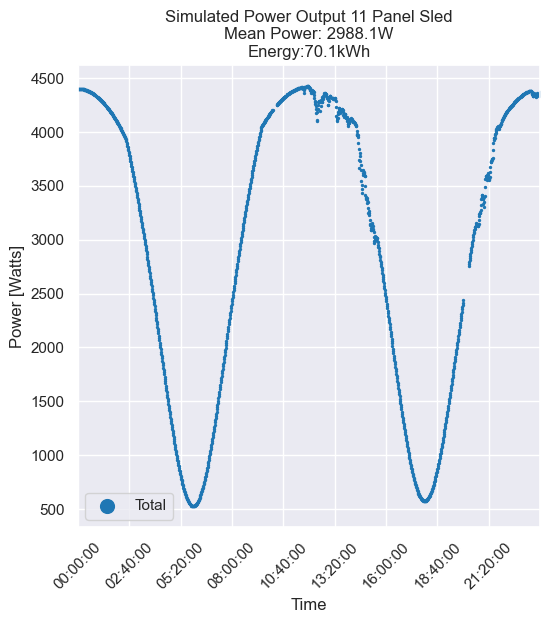

In [68]:
#11 sled Carsten
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin
import seaborn as sns
import math
from VerticalModelFunction import model as VerticalModel
import datetime


# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'

effs= [0.24699832280882955, 0.03850296370170911, 0.05890744297245301]

def serial_date_to_string(year,srl_no):
    '''
    This function turns a day number and year to human readable date. Stole from stack overflow with minor modifactions
    '''
    # This will only work for years in this millenium!
    year_2 = year+2000
    # we need to use a 2 digit year
    new_date = datetime.datetime(year_2,1,1,0,0) + datetime.timedelta(srl_no - 1)
    return new_date.strftime("%Y-%m-%d")


# import NOAA data function
def Import_NOAA_Data(year, day):
    input_1 = year
    input_2 = day
    # -----------------NOAA-----------------------------------
    NOAA = [] #list to hold dataframes
    for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
        iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
        filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
        # print(filename) #print the filename being accessed
    
        try:
            file = urllib.request.urlopen(filename)
            data = file.read().decode('utf-8').split('\n') #read the file and split into lines
            #convert data to dataframe
            df = pd.DataFrame([row.split() for row in data[2:]])
            # print(dt)
            NOAA.append(df) #append dataframe to list
        except urllib.error.HTTPError:
            print()
            # print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    NOAAdir_ir_1 = NOAA[0][12]
    NOAAdir_ir_2 = NOAA[1][12]
    NOAAtemp = NOAA[0][38]
    # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
    # print(f'NOAAtemp: {NOAAtemp}')
    # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
    # concatenate the two days data with time correction
    NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))

    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    # diffuse irradiance
    NOAAdiff_ir_1 = NOAA[0][14]
    NOAAdiff_ir_2 = NOAA[1][14]
    
    # concatenate the two days data with time correction
    NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    NOAAup_ir_1 = NOAA[0][10] 
    NOAAup_ir_2 = NOAA[1][10]
    NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDTup_ir = NZDTup_ir.astype(float)
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula

    '''Solar Zenith Angle'''
    NOAA_Zenith_1 = NOAA[0][7] 
    NOAA_Zenith_2 = NOAA[1][7]
    NZDT_Zenith= pd.concat([NOAA_Zenith_1.iloc[660:1440], NOAA_Zenith_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDT_Zenith = NZDT_Zenith.astype(float)
    #remove nan values from NZDTup_ir 
    NZDT_Zenith[NZDT_Zenith == -9999.9] = np.nan
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time, NZDT_Zenith


day = 8
year = 26

direct_irradiance, diffuse_irradiance, upwelling_irradiance, NOAA_time, solar_zenith = Import_NOAA_Data(year,day)

solar_azimuths = np.linspace(0,360, 10)

solar_zenith_mean = np.nanmean(solar_zenith)
print(solar_zenith_mean)

solar_elevation = 90 - solar_zenith_mean
print(solar_elevation)

panel_height = 1
panel_lift = 0
shadow_length = (panel_height+panel_lift)/np.tan(solar_elevation*np.pi/180)
print(shadow_length)
visual_panel_thickness = .03
panel_length = 2

sled_width = 12.192 
sled_height = 2.4384



# B_D_spacing_diff = (1/2)*(sled_width-((1/3)*(-1*sled_width+np.sqrt(sled_width**2+3*(sled_width**2-8*sled_height*panel_length+4*panel_length**2))))) - panel_length

    

# lets find the power output from VerticalModelFunction

angles = np.concatenate((np.zeros(6),np.repeat([180],5)))

sim_powers = []
for a in angles:
    sim_power = VerticalModel(direct_irradiance, diffuse_irradiance, upwelling_irradiance, effs, 50, solar_zenith_mean, 360-a-90) #there was an error in defining my angle, mismatch the picuture and the model by 90, I correct it here
    sim_powers.append(sim_power)
total_power = np.array(sim_powers).sum(axis=0)
# sim_A, sim_B, sim_C, sim_D = sim_powers

mean_power = np.nanmean(total_power)


fig, ax = plt.subplots(figsize = (12,6))

ax.cla()
ax.set_xlim(0, 1440)
# ax.set_ylim(0, 10)
ax.scatter(np.linspace(0,1440,1440), total_power, s = 2, color = 'tab:blue', label = 'Total')
ax.legend(markerscale = 7)
# ax[1].set_aspect('equal')
ax.set_box_aspect(1)
energy = trapezoid(np.nan_to_num(total_power,nan = 0),dx=60)/(1000*60**2)
ax.set_title(f'Simulated Power Output 11 Panel Sled\nMean Power: {np.round(mean_power,1)}W\nEnergy:{np.round(energy,1)}kWh')
ax.set_xlabel('Time')
ax.set_ylabel('Power [Watts]')
ax.set_xticks(np.linspace(0,1440,1440)[::160],labels = NOAA_time[::160], rotation = 45)



66.96952083333335
23.03047916666665
2.3523723553853015
3.593165907474017



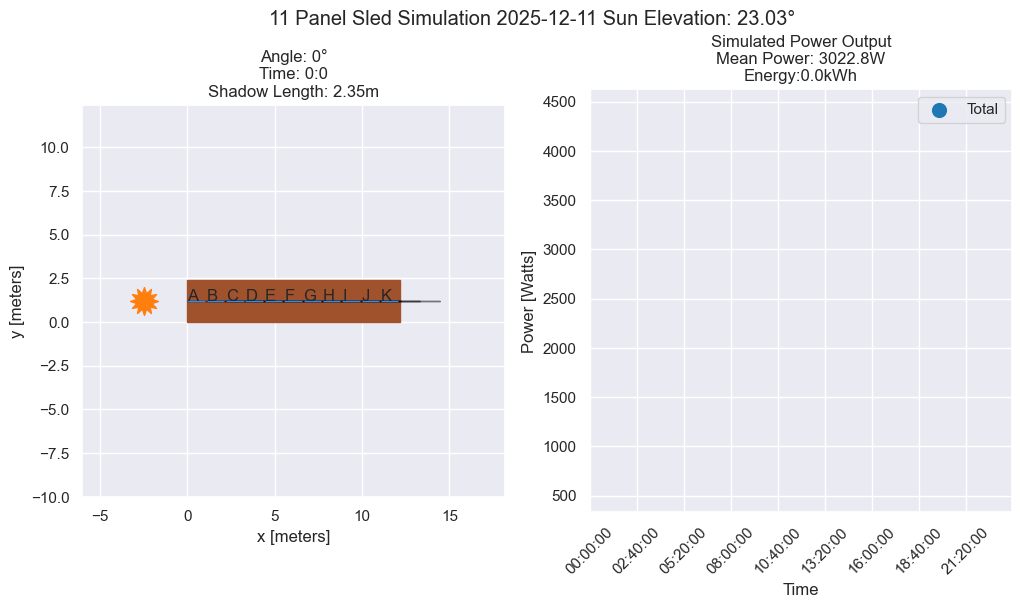

In [65]:
# 11 panel sled w/ animation
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin
import seaborn as sns
import math
from VerticalModelFunction import model as VerticalModel
import datetime


# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'

effs= [0.24699832280882955,0.03850296370170911, 0.05890744297245301]

def serial_date_to_string(year,srl_no):
    '''
    This function turns a day number and year to human readable date. Stole from stack overflow with minor modifactions
    '''
    # This will only work for years in this millenium!
    year_2 = year+2000
    # we need to use a 2 digit year
    new_date = datetime.datetime(year_2,1,1,0,0) + datetime.timedelta(srl_no - 1)
    return new_date.strftime("%Y-%m-%d")


# import NOAA data function
def Import_NOAA_Data(year, day):
    input_1 = year
    input_2 = day
    # -----------------NOAA-----------------------------------
    NOAA = [] #list to hold dataframes
    for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
        iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
        filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
        # print(filename) #print the filename being accessed
    
        try:
            file = urllib.request.urlopen(filename)
            data = file.read().decode('utf-8').split('\n') #read the file and split into lines
            #convert data to dataframe
            df = pd.DataFrame([row.split() for row in data[2:]])
            # print(dt)
            NOAA.append(df) #append dataframe to list
        except urllib.error.HTTPError:
            print()
            # print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    NOAAdir_ir_1 = NOAA[0][12]
    NOAAdir_ir_2 = NOAA[1][12]
    NOAAtemp = NOAA[0][38]
    # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
    # print(f'NOAAtemp: {NOAAtemp}')
    # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
    # concatenate the two days data with time correction
    NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))

    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    # diffuse irradiance
    NOAAdiff_ir_1 = NOAA[0][14]
    NOAAdiff_ir_2 = NOAA[1][14]
    
    # concatenate the two days data with time correction
    NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    NOAAup_ir_1 = NOAA[0][10] 
    NOAAup_ir_2 = NOAA[1][10]
    NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDTup_ir = NZDTup_ir.astype(float)
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula

    '''Solar Zenith Angle'''
    NOAA_Zenith_1 = NOAA[0][7] 
    NOAA_Zenith_2 = NOAA[1][7]
    NZDT_Zenith= pd.concat([NOAA_Zenith_1.iloc[660:1440], NOAA_Zenith_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDT_Zenith = NZDT_Zenith.astype(float)
    #remove nan values from NZDTup_ir 
    NZDT_Zenith[NZDT_Zenith == -9999.9] = np.nan
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time, NZDT_Zenith


day = 345
year = 25

direct_irradiance, diffuse_irradiance, upwelling_irradiance, NOAA_time, solar_zenith = Import_NOAA_Data(year,day)

solar_azimuths = np.linspace(0,360, 10)

solar_zenith_mean = np.nanmean(solar_zenith)
print(solar_zenith_mean)

solar_elevation = 90 - solar_zenith_mean
print(solar_elevation)

panel_height = 1
panel_lift = 0
shadow_length = (panel_height+panel_lift)/np.tan(solar_elevation*np.pi/180)
print(shadow_length)
visual_panel_thickness = .03
panel_length = 1

sled_width = 12.192 
sled_height = 2.4384



# B_D_spacing_diff = (1/2)*(sled_width-((1/3)*(-1*sled_width+np.sqrt(sled_width**2+3*(sled_width**2-8*sled_height*panel_length+4*panel_length**2))))) - panel_length
B_D_spacing_diff = (1/3)*((-1)*np.sqrt(sled_width**2-4*sled_width*panel_length+7*panel_length**2-6*panel_length*sled_height)+2*sled_width-4*panel_length)
print(B_D_spacing_diff)

panel_spacing = sled_width/3-2*visual_panel_thickness
# if shadow_length>panel_spacing:
#     WarningMessage = 'SHADING'
# else:
#     WarningMessage = 'NO SHADING'
WarningMessage = ''
print(WarningMessage)
    

# lets find the power output from VerticalModelFunction

angles = np.concatenate((np.zeros(6),np.repeat([180],5)))

sim_powers = []
for a in angles:
    sim_power = VerticalModel(direct_irradiance, diffuse_irradiance, upwelling_irradiance, effs, 50, solar_zenith_mean, 360-a-90) #there was an error in defining my angle, mismatch the picuture and the model by 90, I correct it here
    sim_powers.append(sim_power)
total_power = np.array(sim_powers).sum(axis=0)
sim_A, sim_B, sim_C, sim_D, sim_E, sim_F, sim_G, sim_H, sim_I, sim_J, sim_K = sim_powers

mean_power = np.nanmean(total_power)





fig, ax = plt.subplots(1,2,figsize = (12,6))

sled = plt.Rectangle((0, 0), width = sled_width, height = sled_height, facecolor = 'sienna', edgecolor = 'sienna')

A_pos = (0,sled_height/2-visual_panel_thickness/2)
B_pos = (sled_width/11,sled_height/2-visual_panel_thickness/2)
C_pos = (2*sled_width/11,sled_height/2-visual_panel_thickness/2)
D_pos = (3*sled_width/11,sled_height/2-visual_panel_thickness/2)
E_pos = (4*sled_width/11,sled_height/2-visual_panel_thickness/2)
F_pos = (5*sled_width/11,sled_height/2-visual_panel_thickness/2)
G_pos = (6*sled_width/11,sled_height/2-visual_panel_thickness/2)
H_pos = (7*sled_width/11,sled_height/2-visual_panel_thickness/2)
I_pos = (8*sled_width/11,sled_height/2-visual_panel_thickness/2)
J_pos = (9*sled_width/11,sled_height/2-visual_panel_thickness/2)
K_pos = (10*sled_width/11,sled_height/2-visual_panel_thickness/2)




def animate(i):

    ax[1].cla()
    ax[1].set_xlim(0, 1440)
    # ax[1].set_ylim(0, 1800)
    ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], total_power[0:int(i*1440/360)], s = 2, color = 'tab:blue', label = 'Total')
    # ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_A[0:int(i*1440/360)], s = 2, color = 'tab:orange', label = 'A')
    # ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_B[0:int(i*1440/360)], s = 2, color = 'tab:green', label = 'B')
    # ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_C[0:int(i*1440/360)], s = 2, color = 'tab:red', label = 'C')
    # ax[1].scatter(np.linspace(0,1440,1440)[0:int(i*1440/360)], sim_D[0:int(i*1440/360)], s = 2, color = 'tab:purple', label = 'D')
    ax[1].legend(markerscale = 7)
    # ax[1].set_aspect('equal')
    ax[1].set_box_aspect(1)
    energy = trapezoid(np.nan_to_num(total_power[0:int(i*1440/360)],nan = 0),dx=60)/(1000*60**2)
    ax[1].set_title(f'Simulated Power Output\nMean Power: {np.round(mean_power,1)}W\nEnergy:{np.round(energy,1)}kWh')
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Power [Watts]')
    ax[1].set_xticks(np.linspace(0,1440,1440)[::160],labels = NOAA_time[::160], rotation = 45)
    


    
    ax[0].cla()
    
    # xmin = -2*shadow_length
    # xmax = 2*shadow_length+sled_width
    # ymin = -4*shadow_length
    # ymax = 4*shadow_length+sled_height
    xmin = -6
    xmax = sled_width+6
    ymin = -10
    ymax = sled_height+10
    ax[0].set_xlim(xmin,xmax)
    ax[0].set_ylim(ymin,ymax)
    ax[0].set_xlabel('x [meters]')
    ax[0].set_ylabel('y [meters]')
    solar_azimuth = i
    # lengths in meters

    
    panel_A = plt.Rectangle(A_pos, height = visual_panel_thickness, width = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_B = plt.Rectangle(B_pos, height = visual_panel_thickness, width = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_C = plt.Rectangle(C_pos, height = visual_panel_thickness, width = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_D = plt.Rectangle(D_pos, height = visual_panel_thickness, width = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_E = plt.Rectangle(E_pos, height = visual_panel_thickness, width = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_F = plt.Rectangle(F_pos, height = visual_panel_thickness, width = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_G = plt.Rectangle(G_pos, height = visual_panel_thickness, width = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_H = plt.Rectangle(H_pos, height = visual_panel_thickness, width = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_I = plt.Rectangle(I_pos, height = visual_panel_thickness, width = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_J = plt.Rectangle(J_pos, height = visual_panel_thickness, width = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    panel_K = plt.Rectangle(K_pos, height = visual_panel_thickness, width = panel_length, facecolor = 'dodgerblue', edgecolor = 'dodgerblue')
    
   

    solar_azimuth = solar_azimuth*np.pi/180  #enter in degrees
    
    
    
    A_shadow_points = [(A_pos[0],visual_panel_thickness/2+A_pos[1]),(A_pos[0]+panel_length,visual_panel_thickness/2+A_pos[1]),(A_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+A_pos[1]+ shadow_length*np.sin(solar_azimuth)),(A_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+A_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_A = Polygon(A_shadow_points, color = 'black', alpha = .5)
    
    B_shadow_points = [(B_pos[0],visual_panel_thickness/2+B_pos[1]),(B_pos[0]+panel_length,visual_panel_thickness/2+B_pos[1]),(B_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+B_pos[1]+ shadow_length*np.sin(solar_azimuth)),(B_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+B_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_B = Polygon(B_shadow_points, color = 'black', alpha = .5)
    
    
    C_shadow_points = [(C_pos[0],visual_panel_thickness/2+B_pos[1]),(C_pos[0]+panel_length,visual_panel_thickness/2+C_pos[1]),(C_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+C_pos[1]+ shadow_length*np.sin(solar_azimuth)),(C_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+C_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_C = Polygon(C_shadow_points, color = 'black', alpha = .5)
    
    
    D_shadow_points = [(D_pos[0],visual_panel_thickness/2+D_pos[1]),(D_pos[0]+panel_length,visual_panel_thickness/2+D_pos[1]),(D_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+D_pos[1]+ shadow_length*np.sin(solar_azimuth)),(D_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+D_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_D = Polygon(D_shadow_points, color = 'black', alpha = .5)


    E_shadow_points = [(E_pos[0],visual_panel_thickness/2+E_pos[1]),(E_pos[0]+panel_length,visual_panel_thickness/2+E_pos[1]),(E_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+E_pos[1]+ shadow_length*np.sin(solar_azimuth)),(E_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+E_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_E = Polygon(E_shadow_points, color = 'black', alpha = .5)

    F_shadow_points = [(F_pos[0],visual_panel_thickness/2+F_pos[1]),(F_pos[0]+panel_length,visual_panel_thickness/2+B_pos[1]),(F_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+F_pos[1]+ shadow_length*np.sin(solar_azimuth)),(F_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+F_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_F = Polygon(F_shadow_points, color = 'black', alpha = .5)

    G_shadow_points = [(G_pos[0],visual_panel_thickness/2+G_pos[1]),(G_pos[0]+panel_length,visual_panel_thickness/2+G_pos[1]),(G_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+G_pos[1]+ shadow_length*np.sin(solar_azimuth)),(G_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+G_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_G = Polygon(G_shadow_points, color = 'black', alpha = .5)

    H_shadow_points = [(H_pos[0],visual_panel_thickness/2+H_pos[1]),(H_pos[0]+panel_length,visual_panel_thickness/2+H_pos[1]),(H_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+H_pos[1]+ shadow_length*np.sin(solar_azimuth)),(H_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+H_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_H = Polygon(H_shadow_points, color = 'black', alpha = .5)

    I_shadow_points = [(I_pos[0],visual_panel_thickness/2+I_pos[1]),(I_pos[0]+panel_length,visual_panel_thickness/2+I_pos[1]),(I_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+I_pos[1]+ shadow_length*np.sin(solar_azimuth)),(I_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+I_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_I = Polygon(I_shadow_points, color = 'black', alpha = .5)

    J_shadow_points = [(J_pos[0],visual_panel_thickness/2+J_pos[1]),(J_pos[0]+panel_length,visual_panel_thickness/2+J_pos[1]),(J_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+J_pos[1]+ shadow_length*np.sin(solar_azimuth)),(J_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+J_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_J = Polygon(J_shadow_points, color = 'black', alpha = .5)
    
    K_shadow_points = [(K_pos[0],visual_panel_thickness/2+K_pos[1]),(K_pos[0]+panel_length,visual_panel_thickness/2+K_pos[1]),(K_pos[0] + shadow_length*np.cos(solar_azimuth)+ panel_length,visual_panel_thickness/2+K_pos[1]+ shadow_length*np.sin(solar_azimuth)),(K_pos[0] + shadow_length*np.cos(solar_azimuth),visual_panel_thickness/2+K_pos[1]+ shadow_length*np.sin(solar_azimuth))]
    shadow_K = Polygon(K_shadow_points, color = 'black', alpha = .5)

    

    
    ax[0].add_patch(sled)

    ax[0].add_patch(shadow_A)
    ax[0].add_patch(shadow_B)
    ax[0].add_patch(shadow_C)
    ax[0].add_patch(shadow_D)
    ax[0].add_patch(shadow_E)
    ax[0].add_patch(shadow_F)
    ax[0].add_patch(shadow_G)
    ax[0].add_patch(shadow_H)
    ax[0].add_patch(shadow_I)
    ax[0].add_patch(shadow_J)
    ax[0].add_patch(shadow_K)
    

    ax[0].add_patch(panel_A)
    ax[0].add_patch(panel_B)
    ax[0].add_patch(panel_C)
    ax[0].add_patch(panel_D)
    ax[0].add_patch(panel_E)
    ax[0].add_patch(panel_F)
    ax[0].add_patch(panel_G)
    ax[0].add_patch(panel_H)
    ax[0].add_patch(panel_I)
    ax[0].add_patch(panel_J)
    ax[0].add_patch(panel_K)
    

    ax[0].text(A_pos[0], A_pos[1], 'A')
    ax[0].text(B_pos[0], B_pos[1], 'B')
    ax[0].text(C_pos[0], C_pos[1], 'C')
    ax[0].text(D_pos[0], D_pos[1], 'D')
    ax[0].text(E_pos[0], E_pos[1], 'E')
    ax[0].text(F_pos[0], F_pos[1], 'F')
    ax[0].text(G_pos[0], G_pos[1], 'G')
    ax[0].text(H_pos[0], H_pos[1], 'H')
    ax[0].text(I_pos[0], I_pos[1], 'I')
    ax[0].text(J_pos[0], J_pos[1], 'J')
    ax[0].text(K_pos[0], K_pos[1], 'K')
    
    # ax[0].text(sled_width/2,sled_height/2,f'{i}°', fontsize = 10, color = 'beige')
    # ax[0].text(sled_width/2,sled_height/4,f'{math.floor(i/15)}:{math.floor((np.round(i/15,2)-math.floor(i/15))*60)}', fontsize = 10, color = 'beige')
    sns.set_theme(style = 'darkgrid')
    ax[0].set_title(f'Angle: {i}°\nTime: {math.floor(i/15)}:{math.floor((np.round(i/15,2)-math.floor(i/15))*60)}\nShadow Length: {np.round(shadow_length, 2)}m')
    ax[0].set_aspect('equal')
    ax[0].text(xmin/2,ymin/2,WarningMessage)

    
    # lets put a ☀️ where the sun is 
    cartoon_solar_distance = 1*shadow_length+np.sqrt(.25*(sled_width**2+sled_height**2))
    ax[0].plot(sled_width/2+cartoon_solar_distance*np.cos((180+i)*np.pi/180),sled_height/2+cartoon_solar_distance*np.sin((180+i)*np.pi/180), marker = "$\u2739$", color = 'tab:orange', markersize = 20)
    
    Date = serial_date_to_string(year, day)
    plt.suptitle(f'11 Panel Sled Simulation {Date} Sun Elevation: {np.round(solar_elevation,3)}°')
    # ax = plt.gca()

    
    # return shadow_A, shadow_B, shadow_C, shadow_D
    # ax.add_patch(shadow_A_2)
    # ax.add_patch(shadow_B_1)
    # ax.add_patch(shadow_B_2)
    # ax.add_patch(shadow_C_1)
    # ax.add_patch(shadow_C_2)
    # ax.add_patch(shadow_D_1)
    # ax.add_patch(shadow_D_2)





# ax.text(-1,-1, f'{sled_width}m', size=20)

# plt.axis('scaled')
# plt.show()
ani = animation.FuncAnimation(
    fig, animate, interval=1, blit=False, frames = 360)
writer = animation.PillowWriter(fps=15,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
ani.save(f'SledArrayDesignes/ElevenLinearSledArray_{year}_{day}.gif', writer=writer)




